# Frozen evaluation, paired uncertainty and limitations

**Question.** How large and stable are differences between the frozen methods on the same monthly target responses?

**Primary estimand:** average seed probabilities separately within each month; calculate paired within-month metric differences; then average the six monthly differences equally. Response-weighted and pooled estimates are secondary. The 5,000-draw paired student bootstrap uses the same sampled learner multiplicities across months. Its intervals condition on frozen predictions and do not include refitting uncertainty.

No model, threshold or calibration choice is changed in this notebook. Data preparation, baseline definitions, sequence proxies and AdaptiveMath-AI implementation belong to Notebooks 01–05.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
for area in ['Data','Models','Tables','Figures']:
    (ROOT/area/'Round2').mkdir(parents=True,exist_ok=True)
(ROOT/'Tables/Round2/manifests').mkdir(parents=True,exist_ok=True)
MODULE_NOTEBOOKS={'round2_analysis': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_data': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_models': ['03_baseline_models_and_error_diagnostics.ipynb', '05_proposed_model_development_and_ablations.ipynb'], 'revision_sensitivity': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_neural': '04_modern_models_and_comparative_diagnostics.ipynb', 'revision_evaluation': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_supplemental': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_provenance': '05_proposed_model_development_and_ablations.ipynb', 'revision_validation': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_closure': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_status': '06_frozen_evaluation_statistics_and_publication_results.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        names=MODULE_NOTEBOOKS[module.__name__]
        names=[names] if isinstance(names,str) else names
        cells=[]
        for name in names:
            notebook=nbformat.read(ROOT/'Notebooks'/name,4)
            cells.extend(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        cells.sort(key=lambda c:c.metadata.get('module_order',0))
        source=''.join(c.source.split('\n',1)[1] for c in cells)
        path=ROOT/'Notebooks'/names[-1]
        module.__file__=str(path)
        module.__notebook_source__=source
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+module.__name__,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line, source):
    """Load the visible definition cells as one module, without external Python files."""
    import importlib
    importlib.import_module(line.strip())

if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.text import Text
from IPython.display import HTML, Image, Markdown
from IPython.utils.capture import capture_output

font_path = font_manager.findfont("Times New Roman", fallback_to_default=False)
mpl.rcParams.update({
    "font.family": "Times New Roman", "font.size": 18,
    "axes.titlesize": 20, "axes.labelsize": 18,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True,
})
pd.set_option("display.max_colwidth", None)

def show_table(frame, title, identifiers=(), width=5, rows=18):
    """Render every scientific row and column in compact, untruncated parts."""
    frame = frame.reset_index(drop=True)
    identifiers = [c for c in identifiers if c in frame]
    values = [c for c in frame if c not in identifiers]
    groups = [values[i:i + width] for i in range(0, len(values), width)] or [[]]
    display(Markdown("**" + title + "**"))
    for start in range(0, max(1, len(frame)), rows):
        for group in groups:
            part = frame.iloc[start:start + rows][identifiers + group]
            def number(x):
                if abs(x) < 5e-12: return "0"
                return f"{x:.3e}" if abs(x) < 1e-4 else f"{x:.6f}".rstrip("0").rstrip(".")
            display(HTML(part.to_html(index=False, border=0, na_rep="Not available",
                                      float_format=number, max_rows=None, max_cols=None)))

def save_canvas(fig, stem):
    """Save and inspect the exact PNG/PDF; display a single PNG below the cell."""
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text().strip():
            assert 18 <= text.get_fontsize() <= 20
            assert Path(font_manager.findfont(text.get_fontproperties(),
                                             fallback_to_default=False)).name == Path(font_path).name
    png = artifact_path("Figures") / (stem + ".png")
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=350)
    fig.savefig(pdf, dpi=350)
    plt.close(fig)
    display(Image(filename=str(png), width=1050))

def load_frozen_predictions():
    """Check recorded file hashes before reading all seed/window predictions."""
    paths = sorted(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))
    assert len(paths) == 60
    for path in paths:
        suffix = path.stem.removeprefix("round2_predictions_")
        manifest = json.loads((artifact_path("manifests") / ("round2_fit_" + suffix + ".json")).read_text())
        assert rd.digest(path) == manifest["prediction_hash"]
    return pd.concat([pd.read_parquet(path) for path in paths], ignore_index=True)


### Imports and constants

In [3]:
%%research_module revision_evaluation
"""Prediction-registry evaluation; no manuscript/report generation."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import json
import time
import platform
import joblib
import numpy as np
import pandas as pd
from numba import njit
from scipy.stats import hypergeom
from sklearn.metrics import roc_auc_score
from threadpoolctl import threadpool_limits,threadpool_info
from revision_data import ROOT,V,KEYS,FEATURES,protocol,digest,save_json,table,EventReplay,fit_representation
from revision_models import metrics,predict,calibrate,hierarchy_apply,prediction_frame



### bootstrap metrics

In [4]:
%%research_module revision_evaluation
@njit
def bootstrap_metrics(y,p,w,order,extended=True):
    n=len(y);mass=w.sum();pos=(w*y).sum();neg=mass-pos
    out=np.full(8,np.nan)
    if mass<=0 or pos<=0 or neg<=0:return out
    auc=0.;cneg=0.;ll=0.;brier=0.;eb=np.zeros(15)
    i=0
    while i<n:
        j=i;gp=0.;gn=0.;pv=p[order[i]]
        while j<n and p[order[j]]==pv:
            ix=order[j];gp+=w[ix]*y[ix];gn+=w[ix]*(1-y[ix]);j+=1
        auc+=gp*(cneg+.5*gn);cneg+=gn;i=j
    for i in range(n):
        ll+=w[i]*(-y[i]*np.log(p[i])-(1-y[i])*np.log1p(-p[i]));brier+=w[i]*(y[i]-p[i])**2
        b=min(int(p[i]*15),14);eb[b]+=w[i]*(y[i]-p[i])
    out[0]=auc/(pos*neg);out[1]=ll/mass;out[2]=brier/mass;out[3]=np.abs(eb).sum()/mass
    if not extended:return out
    tp=fp=ap=0.;i=n-1
    while i>=0:
        j=i;gp=gn=0.;pv=p[order[i]]
        while j>=0 and p[order[j]]==pv:
            ix=order[j];gp+=w[ix]*y[ix];gn+=w[ix]*(1-y[ix]);j-=1
        tp+=gp;fp+=gn
        if tp+fp>0:ap+=gp/pos*tp/(tp+fp)
        i=j
    out[4]=ap
    tp=fp=ap=0.;i=0
    while i<n:
        j=i;gp=gn=0.;pv=p[order[i]]
        while j<n and p[order[j]]==pv:
            ix=order[j];gp+=w[ix]*(1-y[ix]);gn+=w[ix]*y[ix];j+=1
        tp+=gp;fp+=gn
        if tp+fp>0:ap+=gp/neg*tp/(tp+fp)
        i=j
    out[5]=ap
    x=np.log(p/(1-p));a=0.;b=1.;converged=False
    for iteration in range(40):
        g0=g1=h00=h01=h11=0.
        for j in range(n):
            z=min(max(a+b*x[j],-40),40);r=1/(1+np.exp(-z));grad=w[j]*(y[j]-r);curv=w[j]*r*(1-r)
            g0+=grad;g1+=grad*x[j];h00+=curv;h01+=curv*x[j];h11+=curv*x[j]*x[j]
        det=h00*h11-h01*h01
        if det<1e-12:break
        da=(h11*g0-h01*g1)/det;db=(h00*g1-h01*g0)/det
        scale=max(1.,abs(da)/2,abs(db)/2);a+=da/scale;b+=db/scale
        if max(abs(da),abs(db))<1e-7:converged=True;break
    if converged:out[6]=a;out[7]=b
    return out

METRIC_NAMES=['ROC_AUC','Log_Loss','Brier','ECE15','AP_correct','AP_incorrect','Calibration_Intercept','Calibration_Slope']



### paired bootstrap

In [5]:
%%research_module revision_evaluation
def paired_bootstrap(frame,pa,pb,method='student',B=None,seed=20260713,extended=True,name='primary',base_weights=None):
    B=protocol()['bootstrap_B'] if B is None else B
    y=frame.y.to_numpy(float);pa=np.clip(np.asarray(pa,float),1e-6,1-1e-6);pb=np.clip(np.asarray(pb,float),1e-6,1-1e-6)
    ui,ul=pd.factorize(frame.UserId,sort=True);qi,ql=pd.factorize(frame.QuestionId,sort=True);rng=np.random.default_rng(seed)
    oa=np.argsort(pa);ob=np.argsort(pb);draws=np.full((B,8),np.nan);a_draws=np.full_like(draws,np.nan);b_draws=np.full_like(draws,np.nan)
    for b in range(B):
        if method=='student':w=rng.multinomial(len(ul),np.ones(len(ul))/len(ul))[ui].astype(float)
        elif method=='question':w=rng.multinomial(len(ql),np.ones(len(ql))/len(ql))[qi].astype(float)
        elif method=='crossed':w=(rng.multinomial(len(ul),np.ones(len(ul))/len(ul))[ui]*rng.multinomial(len(ql),np.ones(len(ql))/len(ql))[qi]).astype(float)
        elif method in ['GroupId','QuizId']:
            if b==0:extra,levels=pd.factorize(frame[method],sort=True)
            w=rng.multinomial(len(levels),np.ones(len(levels))/len(levels))[extra].astype(float)
        else:raise ValueError(method)
        if base_weights is not None:w=w*np.asarray(base_weights)
        a=bootstrap_metrics(y,pa,w,oa,extended);c=bootstrap_metrics(y,pb,w,ob,extended);a_draws[b]=a;b_draws[b]=c;draws[b]=a-c
        if (b+1)%1000==0:print(f'{name} / {method}: {b+1}/{B} paired resamples',flush=True)
    result=[]
    for j,metric in enumerate(METRIC_NAMES):
        if not extended and j>=4:continue
        z=draws[:,j];valid=z[np.isfinite(z)];n=len(valid);le=int((valid<=0).sum());ge=int((valid>=0).sum())
        pw=np.ones(len(y)) if base_weights is None else np.asarray(base_weights)
        point=bootstrap_metrics(y,pa,pw,oa,extended)[j]-bootstrap_metrics(y,pb,pw,ob,extended)[j]
        result.append({'contrast':name,'cluster':method,'metric':metric,'delta':point,'lower':np.quantile(valid,.025) if n else np.nan,'upper':np.quantile(valid,.975) if n else np.nan,'B_requested':B,'B_valid':n,'B_invalid':B-n,'count_delta_le0':le,'count_delta_ge0':ge,'p_two_sided':min(1,2*(min(le,ge)+1)/(n+1)) if n else np.nan,'p_formula':'min(1, 2*(min(count<=0,count>=0)+1)/(B_valid+1))','minimum_p_resolution':2/(n+1),'uncertainty':'conditional on fixed fitted predictions; seed variability separate','estimator':'crossed independent multinomial pigeonhole product weights' if method=='crossed' else 'paired cluster multiplicity weights', 'model_lower':np.nanquantile(a_draws[:,j],.025),'model_upper':np.nanquantile(a_draws[:,j],.975),'comparator_lower':np.nanquantile(b_draws[:,j],.025),'comparator_upper':np.nanquantile(b_draws[:,j],.975)})
    pd.DataFrame(draws,columns=METRIC_NAMES).to_parquet(artifact_path('Tables')/f'bootstrap_draws_{name}_{method}.parquet',index=False)
    return pd.DataFrame(result)



### aggregate primary

In [6]:
%%research_module revision_evaluation
def aggregate_primary():
    paths=sorted((artifact_path('Data')).glob('predictions_seed*_fold*.parquet'));expected=protocol()['outer_folds']*len(protocol()['seeds'])
    if len(paths)!=expected:raise RuntimeError(f'Primary predictions incomplete: {len(paths)}/{expected} folds; no silent budget reduction.')
    sums=None;counts=None;metadata=[];seed_rows=[]
    for seed in protocol()['seeds']:
        parts=[pd.read_parquet(p) for p in paths if f'seed{seed}_' in p.name];d=pd.concat(parts,ignore_index=True)
        if d.duplicated(['model','AnswerId']).any():raise AssertionError('Duplicate outer targets per seed')
        p=d.set_index(['model','AnswerId']).p
        sums=p if sums is None else sums.add(p,fill_value=0);ones=p*0+1;counts=ones if counts is None else counts.add(ones,fill_value=0)
        if not metadata:metadata.append(d.drop(columns=['p','seed','model_hash']))
        for name,g in d.groupby('model'):seed_rows.append({'seed':seed,'model':name,'N':len(g),**metrics(g.y,g.p)})
    assert counts.eq(len(protocol()['seeds'])).all()
    mean=(sums/counts).rename('p').reset_index();meta=metadata[0];d=meta.merge(mean,on=['model','AnswerId'],validate='one_to_one');d['prediction_kind']='mean_temporal_outer_probabilities';d['seed']=-1
    d.to_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'),index=False)
    table('per_seed_metrics.csv',pd.DataFrame(seed_rows),'NB06')
    records=[]
    for name,g in d.groupby('model'):
        for weighting in ['interaction','equal_student']:
            w=None if weighting=='interaction' else 1/g.groupby('UserId').UserId.transform('size').to_numpy()
            records.append({'model':name,'scenario':'global_calendar_learner_feedback','prediction_kind':'mean_temporal_outer_probabilities','weighting':weighting,'N':len(g),'students':g.UserId.nunique(),'questions':g.QuestionId.nunique(),'prevalence':g.y.mean(),**metrics(g.y,g.p,w)})
    seeds=pd.DataFrame(seed_rows);estimands=[]
    for name,g in d.groupby('model'):
        s=seeds[seeds.model.eq(name)]
        estimands.append({'model':name,'AUC_mean_probabilities':roc_auc_score(g.y,g.p),'mean_seed_AUC':s.ROC_AUC.mean(),'seed_AUC_SD':s.ROC_AUC.std(),'seed_AUC_q025':s.ROC_AUC.quantile(.025),'seed_AUC_q975':s.ROC_AUC.quantile(.975),'training_variability_scope':'Fixed temporal splits and deterministic HGB may produce identical seed fits; not independent datasets.'})
    table('estimand_comparison.csv',pd.DataFrame(estimands),'NB06')
    return table('metrics_by_scenario.csv',pd.DataFrame(records),'NB06')



### uncertainty

In [7]:
%%research_module revision_evaluation
def uncertainty():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));a=d[d.model.eq('AdaptiveMath-AI')].sort_values('AnswerId');b=d[d.model.eq('HGB100')].set_index('AnswerId').loc[a.AnswerId]
    results=[]
    for method in ['student','question','crossed']:
        print('Bootstrap primary',method,'B=5000',flush=True)
        result=paired_bootstrap(a,a.p,b.p,method,name='Adaptive_vs_HGB100')
        result['test_family']=np.where((result.metric=='ROC_AUC')&(result.cluster=='student'),'designated_primary_contrast','supporting_or_dependence_sensitivity')
        result['interpretation']='Retrospective technical evaluation; nominal supporting p-values do not establish independent confirmation.'
        results.append(result)
        table('paired_uncertainty.csv',pd.concat(results,ignore_index=True),'NB06')
    weights=1/a.groupby('UserId').UserId.transform('size').to_numpy()
    weighted=paired_bootstrap(a,a.p,b.p,'student',extended=False,name='Adaptive_vs_HGB100_equal_student',base_weights=weights)
    table('equal_student_paired_uncertainty.csv',weighted,'NB06')
    secondary=[]
    # Plus_hierarchy and No_calibration are the identical prediction recipe.
    # Report both point estimates, but do not count the same hypothesis twice.
    left=d[d.model.eq('Plus_hierarchy')].set_index('AnswerId').p
    right=d[d.model.eq('No_calibration')].set_index('AnswerId').p.reindex(left.index)
    np.testing.assert_array_equal(left,right)
    table('prediction_recipe_aliases.csv',pd.DataFrame([{'alias':'Plus_hierarchy','canonical_recipe':'No_calibration','reason':'Identical uncalibrated full-hierarchy predictions; one paired CI and one Holm hypothesis.'}]),'NB06')
    for comparator in ['HGB80_anchor','Plus_question_memory','No_calibration','Ablation_no_question','Ablation_no_subject']:
        z=d[d.model.eq(comparator)].set_index('AnswerId').loc[a.AnswerId]
        result=paired_bootstrap(a,a.p,z.p,'student',extended=False,name='Adaptive_vs_'+comparator);result['family']='matched_ablation';secondary.append(result)
    # Existing one-step versus converged item-intercept comparison: same lambda and cap.
    q=d[d.model.eq('Plus_question_memory')].sort_values('AnswerId');c=d[d.model.eq('Converged_item_intercept')].set_index('AnswerId').loc[q.AnswerId]
    comp=paired_bootstrap(q,q.p,c.p,'student',extended=False,name='one_step_vs_converged');comp['family']='mechanism';secondary.append(comp)
    sec=pd.concat(secondary,ignore_index=True);sec['Holm_p']=np.nan
    for _,idx in sec.groupby(['family','metric']).groups.items():
        indices=np.asarray(list(idx));order=indices[np.argsort(sec.loc[indices,'p_two_sided'])];m=len(order);sec.loc[order,'Holm_p']=np.minimum(1,np.maximum.accumulate(sec.loc[order,'p_two_sided'].to_numpy()*(m-np.arange(m))))
    table('secondary_paired_uncertainty.csv',sec,'NB06')
    return pd.concat(results,ignore_index=True)



### frozen scenarios

In [8]:
%%research_module revision_evaluation
def frozen_scenarios():
    pr=protocol();base=pd.read_parquet(artifact_path('Data/features_primary.parquet'));start=pd.Timestamp(pr['calendar']['initial_calibration_end'],tz='UTC')
    variants={'learner_feedback':base[base.DateAnswered>=start]}
    for mode in ['outcome_free','no_feedback']:
        d=pd.read_parquet(artifact_path('Data')/f'features_{mode}.parquet');variants[mode]=d[d.DateAnswered>=start]
    for h in pr['history_caps']:variants[f'history_cap_{h}']=pd.read_parquet(artifact_path('Data')/f'history_cap_features_{h}.parquet')
    parts=[];summary=[]
    for seed in pr['seeds']:
        for name in ['HGB80','HGB100','AdaptiveMath-AI']:
            path=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold0.joblib';obj=joblib.load(path)
            for scenario,frame in variants.items():
                p=predict(obj['anchor'],frame);route=None
                if obj['memory'] is not None:p,route=hierarchy_apply(frame,p,obj['memory'])
                p=calibrate(obj['calibrator'],p);parts.append(prediction_frame(frame,p,name,seed,0,'frozen_object',scenario,digest(path),route))
                summary.append({'model':name,'scenario':scenario,'seed':seed,'prediction_kind':'frozen_object','N':len(frame),**metrics(frame.IsCorrect,p)})
        pd.concat(parts,ignore_index=True).to_parquet(artifact_path('Data')/f'frozen_scenarios_seed{seed}.parquet',index=False);parts=[]
    return table('frozen_scenario_metrics.csv',pd.DataFrame(summary),'NB06')



### subgroup and review

In [9]:
%%research_module revision_evaluation
def subgroup_and_review():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));rows=[];bins=[];review=[];risks=[]
    for name,g in d[d.model.isin(['AdaptiveMath-AI','HGB100'])].groupby('model'):
        for count,freq in [(10,False),(15,False),(15,True)]:bins.append({'model':name,'bins':count,'equal_frequency':freq,**metrics(g.y,g.p,bins=count,equal_frequency=freq)})
        g=g.copy();g['history_bin']=pd.cut(g.prior_interaction_count,[-1,0,4,9,19,49,np.inf]).astype(str)
        for field in ['Gender','PremiumPupil','history_bin','route']:
            if field not in g:continue
            for value,s in g.groupby(field,dropna=False):
                enough=len(s)>=100 and s.UserId.nunique()>=20 and s.y.nunique()==2
                rows.append({'model':name,'group_field':field,'group':str(value),'N':len(s),'students':s.UserId.nunique(),'questions':s.QuestionId.nunique(),'prevalence':s.y.mean(),'status':'estimable' if enough else 'low_support',**(metrics(s.y,s.p) if enough else {})})
        p=g.p.to_numpy();failure=(1-g.y).to_numpy();error=((p>=.5)!=g.y).to_numpy();n=len(g);F=int(failure.sum());ids=g.AnswerId.to_numpy()
        entropy=-p*np.log(p)-(1-p)*np.log1p(-p)
        for budget in protocol()['review_budgets']:
            k=int(np.floor(budget*n))
            for score_name,score in [('entropy',entropy),('one_minus_p',1-p)]:
                order=np.lexsort((ids,-score));selected=np.zeros(n,bool);selected[order[:k]]=True;found=int(failure[selected].sum());accepted=~selected
                review.append({'model':name,'policy':score_name,'budget':budget,'N':n,'reviewed':k,'incorrect_found':found,'incorrect_missed':F-found,'selection_precision':found/k,'selection_recall':found/max(F,1),'accepted_classifier_error':error[accepted].mean(),'coverage':accepted.mean(),'mode':'diagnostic top-k; AnswerId ties only for selection, no labels used for ordering'})
                # Conditional selected set: paired learner bootstrap for classifier risk.
                by=pd.DataFrame({'u':g.UserId,'err':error*accepted,'accepted':accepted.astype(int)}).groupby('u')[['err','accepted']].sum().to_numpy();rng=np.random.default_rng(20260713);B=protocol()['bootstrap_B'];draw=[]
                for _ in range(B):
                    mult=rng.multinomial(len(by),np.ones(len(by))/len(by));total=mult@by
                    if total[1]:draw.append(total[0]/total[1])
                risks.append({'model':name,'policy':score_name,'budget':budget,'coverage':accepted.mean(),'risk':error[accepted].mean(),'lower':np.quantile(draw,.025),'upper':np.quantile(draw,.975),'B_valid':len(draw),'CI_scope':'student bootstrap conditional on fixed diagnostic top-k set'})
            expectation=k*F/n;lo,hi=hypergeom.ppf([.025,.975],n,F,k)
            review.append({'model':name,'policy':'random_expectation','budget':budget,'N':n,'reviewed':k,'incorrect_found':expectation,'incorrect_missed':F-expectation,'selection_precision':F/n,'selection_recall':k/n,'accepted_classifier_error':error.mean(),'coverage':1-k/n,'random_found_lower':lo,'random_found_upper':hi,'mode':'exact hypergeometric random-selection distribution at same budget'})
            rlo,rhi=hypergeom.ppf([.025,.975],n,int(error.sum()),n-k)/(n-k)
            risks.append({'model':name,'policy':'random_expectation','budget':budget,'coverage':1-k/n,'risk':error.mean(),'lower':rlo,'upper':rhi,'B_valid':np.nan,'CI_scope':'exact finite-population random-selection interval; not a fitted-procedure confidence interval'})
    table('binning_sensitivity.csv',pd.DataFrame(bins),'NB06');table('subgroup_history_calibration.csv',pd.DataFrame(rows),'NB06');table('risk_coverage_with_ci.csv',pd.DataFrame(risks),'NB06')
    return table('review_budget_comparison.csv',pd.DataFrame(review),'NB06')



### subgroup and scenario intervals

In [10]:
%%research_module revision_evaluation
def subgroup_and_scenario_intervals():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));a=d[d.model.eq('AdaptiveMath-AI')].copy();b=d[d.model.eq('HGB100')].set_index('AnswerId')
    a['history_bin']=pd.cut(a.prior_interaction_count,[-1,0,4,9,19,49,np.inf]).astype(str)
    a['support_bin']=pd.cut(a.support_n,[-1,0,4,9,19,49,np.inf]).astype(str)
    cold=pd.read_parquet(artifact_path('Data/cold_start_slice_manifest.parquet'));a=a.merge(cold[['AnswerId','first_response','first_5','known_training_question','known_training_student']],on='AnswerId',validate='one_to_one')
    a=a.rename(columns={'known_training_question':'known_initial_prefix_question','known_training_student':'known_initial_prefix_student'})
    # Advancing outer models see additional pre-window events. Do not label
    # a fixed initial-prefix slice as model-specific cold start.
    a['known_outer_fit_question']=False;a['known_outer_fit_student']=False
    for fold,g in a.groupby('fold'):
        ids=pd.read_parquet(artifact_path('Data')/f'fitting_ids_seed{protocol()["seeds"][0]}_fold{fold}.parquet')
        ids=ids[ids.model.eq('HGB100')]
        a.loc[g.index,'known_outer_fit_question']=g.QuestionId.isin(ids.QuestionId)
        a.loc[g.index,'known_outer_fit_student']=g.UserId.isin(ids.UserId)
    a[['AnswerId','fold','first_response','first_5','known_initial_prefix_question','known_initial_prefix_student','known_outer_fit_question','known_outer_fit_student']].to_parquet(artifact_path('Data/cold_start_outer_slice_manifest.parquet'),index=False)
    results=[];points=[]
    fields=['Gender','PremiumPupil','history_bin','route','support_bin','known_initial_prefix_question','known_initial_prefix_student','known_outer_fit_question','known_outer_fit_student','first_response','first_5','primary_subject_id']
    for field in fields:
        for value,g in a.groupby(field,dropna=False):
            minimum=1000 if field=='primary_subject_id' else 100
            estimable=len(g)>=minimum and g.UserId.nunique()>=20 and g.y.nunique()==2
            comp=b.loc[g.AnswerId]
            for name,prob in [('AdaptiveMath-AI',g.p),('HGB100',comp.p)]:
                points.append({'model':name,'group_field':field,'group':str(value),'N':len(g),'students':g.UserId.nunique(),'questions':g.QuestionId.nunique(),'prevalence':g.y.mean(),'status':'estimable' if estimable else 'low_support',**(metrics(g.y,prob) if estimable else {})})
            if not estimable:continue
            tag='subgroup_'+field+'_'+str(len(results));r=paired_bootstrap(g,g.p,comp.p,extended=False,name=tag);r['group_field']=field;r['group']=str(value);r['N']=len(g);results.append(r)
        print('Subgroup intervals completed',field,flush=True)
    table('subgroup_history_calibration.csv',pd.DataFrame(points),'NB06')
    table('subgroup_dependence_aware_intervals.csv',pd.concat(results,ignore_index=True),'NB06')
    sums=None;meta=None
    for seed in protocol()['seeds']:
        f=pd.read_parquet(artifact_path('Data')/f'frozen_scenarios_seed{seed}.parquet');f=f[f.model.isin(['AdaptiveMath-AI','HGB80','HGB100'])]
        p=f.set_index(['model','scenario','AnswerId']).p
        sums=p if sums is None else sums.add(p,fill_value=0)
        if meta is None:meta=f.drop(columns=['p','seed','model_hash'])
    ensemble=(sums/len(protocol()['seeds'])).rename('p').reset_index();ensemble=meta.merge(ensemble,on=['model','scenario','AnswerId'],validate='one_to_one');ensemble['seed']=-1;ensemble['prediction_kind']='mean_frozen_object_probabilities';ensemble.to_parquet(artifact_path('Data/frozen_ensemble_predictions.parquet'),index=False)
    rows=[];cis=[]
    for scenario,g in ensemble.groupby('scenario'):
        x=g[g.model.eq('AdaptiveMath-AI')].sort_values('AnswerId');y=g[g.model.eq('HGB100')].set_index('AnswerId').loc[x.AnswerId]
        for name,h in g.groupby('model'):
            for weighting in ['interaction','equal_student']:
                w=None if weighting=='interaction' else 1/h.groupby('UserId').UserId.transform('size').to_numpy()
                rows.append({'model':name,'scenario':scenario,'prediction_kind':'mean_frozen_object_probabilities','weighting':weighting,'N':len(h),'students':h.UserId.nunique(),'questions':h.QuestionId.nunique(),'prevalence':h.y.mean(),**metrics(h.y,h.p,w)})
        c=paired_bootstrap(x,x.p,y.p,extended=False,name='scenario_'+scenario);c['scenario']=scenario;cis.append(c)
        print('Frozen scenario intervals completed',scenario,flush=True)
    table('frozen_scenario_paired_intervals.csv',pd.concat(cis,ignore_index=True),'NB06')
    primary=pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv'));table('metrics_by_scenario.csv',pd.concat([primary,pd.DataFrame(rows)],ignore_index=True),'NB06')
    return pd.concat(cis,ignore_index=True)



### permutation and latency

In [11]:
%%research_module revision_evaluation
@threadpool_limits.wrap(limits=4)
def permutation_and_latency():
    pr=protocol();seed=pr['seeds'][0];d=pd.read_parquet(artifact_path('Data/features_primary.parquet'));ev=d[d.split.eq('evaluation')].copy()
    groups={'question_rate':['question_historical_accuracy','question_difficulty','rasch_question_difficulty'],'collaborative':['student_question_similarity','matrix_factorization_score','collaborative_state_norm'],'learner_counts':['prior_interaction_count','prior_correct_count','prior_cumulative_accuracy','rasch_ability'],'learner_recent':['rolling_accuracy_5','rolling_accuracy_20','rolling_accuracy_50','ewm_accuracy'],'learner_concept':['prior_subject_opportunities','prior_subject_accuracy','bkt_mastery'],'elo':['elo_student_ability','elo_probability']}
    rows=[];latency=[];bulk=[]
    for name in ['AdaptiveMath-AI','HGB100']:
        path=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold0.joblib';obj=joblib.load(path)
        def inference(frame):
            p=predict(obj['anchor'],frame)
            if obj['memory'] is not None:p,_=hierarchy_apply(frame,p,obj['memory'])
            return calibrate(obj['calibrator'],p)
        base=roc_auc_score(ev.IsCorrect,inference(ev));rng=np.random.default_rng(seed)
        batch=ev.iloc[:min(10000,len(ev))]
        inference(batch)
        for repeat in range(5):
            t=time.perf_counter_ns();inference(batch);elapsed=(time.perf_counter_ns()-t)/1e6
            bulk.append({'model':name,'model_hash':digest(path),'repeat':repeat,'rows':len(batch),'total_ms':elapsed,'amortized_ms_per_row':elapsed/len(batch),'scope':'Prepared DataFrame inference only; excludes event feature/state work. Not online event latency.','threads':4})
        for group,cols in groups.items():
            for repeat in range(5):
                perm=ev.copy();ix=rng.permutation(len(ev));perm.loc[:,cols]=ev.iloc[ix][cols].to_numpy();rows.append({'model':name,'group':group,'columns':json.dumps(cols),'repeat':repeat,'ROC_AUC_drop':base-roc_auc_score(ev.IsCorrect,inference(perm)),'split':'frozen global-calendar evaluation','model_hash':digest(path),'interpretation':'Predictive dependence-group perturbation; not causal importance.'})
        events=pd.read_parquet(artifact_path('Data')/f'events_{pr["cohort"]["salt"]}.parquet');factors,_=fit_representation(events,pr['calendar']['representation_end']);start=ev.DateAnswered.min();state=EventReplay(factors=factors,item_fit_end=pr['calendar']['representation_end'])
        for stamp,g in events[events.DateAnswered<start].groupby('DateAnswered',sort=False):state.update_batch(list(g.itertuples(index=False)),stamp)
        import copy
        saved=copy.deepcopy(state);stream=list(events[events.DateAnswered>=start].groupby('DateAnswered',sort=False))[:200]
        for rep in range(6):
            state=copy.deepcopy(saved);measure=[]
            for stamp,g in stream:
                batch=list(g.itertuples(index=False));t0=time.perf_counter_ns();values=state.emit_batch(batch);t1=time.perf_counter_ns();frame=g.copy()
                for j,c in enumerate(FEATURES):frame[c]=values[:,j]
                inference(frame);t2=time.perf_counter_ns();state.update_batch(batch,stamp);t3=time.perf_counter_ns()
                if rep:measure.append({'features_ms':(t1-t0)/1e6,'prediction_ms':(t2-t1)/1e6,'state_update_ms':(t3-t2)/1e6,'event_batch_ms':(t3-t0)/1e6,'batch_size':len(g)})
            if rep:
                for metric in ['features_ms','prediction_ms','state_update_ms','event_batch_ms']:
                    a=np.array([x[metric] for x in measure]);latency.append({'model':name,'model_hash':digest(path),'repeat':rep,'component':metric,'median':np.median(a),'p95':np.quantile(a,.95),'p99':np.quantile(a,.99),'unit':'milliseconds per timestamp batch','timestamp_batches':len(stream),'events':sum(x['batch_size'] for x in measure),'state_reset':'exact deepcopy of pre-stream state per repetition','warmup_repetitions':1,'hardware':platform.platform(),'threads':4})
    table('dependency_group_permutation.csv',pd.DataFrame(rows),'NB06')
    table('prepared_frame_inference_latency.csv',pd.DataFrame(bulk),'NB06')
    save_json(artifact_path('latency_runtime.json'),{'threadpools':threadpool_info(),'configured_limit':4,'hardware':platform.platform(),'warmup':1,'measured_repetitions':5,'stream_timestamp_batches':200})
    return table('event_stream_latency.csv',pd.DataFrame(latency),'NB06')



### additional cluster sensitivity

In [12]:
%%research_module revision_evaluation
def additional_cluster_sensitivity():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));a=d[d.model.eq('AdaptiveMath-AI')].copy();b=d[d.model.eq('HGB100')].set_index('AnswerId')
    meta=pd.read_parquet(artifact_path('Data/features_primary.parquet'),columns=['AnswerId','GroupId','QuizId'])
    a=a.drop(columns=['GroupId','QuizId'],errors='ignore').merge(meta,on='AnswerId',validate='one_to_one')
    records=[];support=[]
    for field in ['GroupId','QuizId']:
        g=a[a[field].notna()].copy();clusters=g[field].nunique();eligible=clusters>=30 and g.y.nunique()==2
        support.append({'cluster':field,'N':len(g),'clusters':clusters,'missing_rows':len(a)-len(g),'status':'estimable' if eligible else 'DATA_LIMITATION','scope':'One-way cluster sensitivity, not an independent validation cohort.'})
        if eligible:
            r=paired_bootstrap(g,g.p,b.loc[g.AnswerId].p,method=field,extended=False,name='extra_cluster_'+field);records.append(r)
    table('additional_cluster_support.csv',pd.DataFrame(support),'NB06')
    return table('additional_cluster_intervals.csv',pd.concat(records,ignore_index=True) if records else pd.DataFrame(support),'NB06')



### diagnostic figures

In [13]:
%%research_module revision_evaluation
def diagnostic_figures():
    import matplotlib.pyplot as plt
    from IPython.display import Image, display
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('png')
    plt.rcParams.update({'font.family':'Times New Roman','font.size':11,'figure.dpi':350,'savefig.dpi':350})
    def publish(fig, name):
        path=artifact_path('Figures')/name
        fig.savefig(path, dpi=350)
        plt.close(fig)
        # Embed the exported raster itself; inline/retina settings cannot rescale it.
        display(Image(filename=str(path)))
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));fig,ax=plt.subplots(figsize=(4.2,3.8))
    for name in ['AdaptiveMath-AI','HGB100']:
        g=d[d.model.eq(name)].copy();g['bin']=np.minimum((g.p*15).astype(int),14);points=g.groupby('bin').agg(p=('p','mean'),observed=('y','mean'),N=('y','size'));ax.plot(points.p,points.observed,'o-',label=name)
    ax.plot([0,1],[0,1],'--',color='gray');ax.set(xlabel='Predicted probability',ylabel='Observed correctness',title='Calibration: 15 equal-width bins');ax.legend(frameon=False);fig.tight_layout();publish(fig,'revision_calibration.png')
    risk=pd.read_csv(artifact_path('Tables/risk_coverage_with_ci.csv'));fig,ax=plt.subplots(figsize=(4.6,3.5))
    for policy,g in risk[risk.model.eq('AdaptiveMath-AI')].groupby('policy'):
        g=g.sort_values('coverage');ax.plot(g.coverage,g.risk,'o-',label=policy);ax.fill_between(g.coverage,g.lower,g.upper,alpha=.15)
    ax.set(xlabel='Accepted prediction coverage',ylabel='Classifier error rate',title='Conditional risk–coverage');ax.legend(frameon=False);fig.tight_layout();publish(fig,'revision_risk_coverage.png')
    met=pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv'));ci=pd.read_csv(artifact_path('Tables/frozen_scenario_paired_intervals.csv'));caps=protocol()['history_caps'];fig,ax=plt.subplots(figsize=(4.8,3.6))
    for name,prefix in [('AdaptiveMath-AI','model'),('HGB100','comparator')]:
        yy=[];lo=[];hi=[]
        for h in caps:
            scenario=f'history_cap_{h}';r=met[(met.model==name)&(met.scenario==scenario)&(met.weighting=='interaction')].iloc[0];c=ci[(ci.scenario==scenario)&(ci.metric=='ROC_AUC')].iloc[0];yy.append(r.ROC_AUC);lo.append(c[prefix+'_lower']);hi.append(c[prefix+'_upper'])
        x=np.arange(len(caps));ax.plot(x,yy,'o-',label=name);ax.fill_between(x,lo,hi,alpha=.15)
    ax.set_xticks(np.arange(len(caps)),caps);ax.set(xlabel='Maximum available prior events',ylabel='ROC–AUC',title='Fixed-target history sensitivity');ax.legend(frameon=False);fig.tight_layout();publish(fig,'revision_fixed_target_history.png')
    curves=pd.read_parquet(artifact_path('Tables/learning_curves.parquet'));curves=curves[curves.seed==protocol()['neural']['seeds'][0]];fig,ax=plt.subplots(figsize=(5.2,3.7))
    for (name,rate),g in curves.groupby(['model','learning_rate']):ax.plot(g.epoch,g.development_loss,label=f'{"GRU" if "GRU" in name else "SAKT"}, lr={rate:g}')
    ax.set(xlabel='Epoch',ylabel='Development log loss',title='Matched-information learning curves');ax.legend(frameon=False,fontsize=9);fig.tight_layout();publish(fig,'revision_learning_curves.png')

### Imports and constants

In [14]:
%%research_module revision_supplemental
"""Prespecified single-factor diagnostics, separate from the 10-seed primary run."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import copy
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from threadpoolctl import threadpool_limits
from revision_data import ROOT,V,KEYS,FEATURES,protocol,table,save_json,register,digest,EventReplay,fit_representation
from revision_models import fit_frozen,temporal_parts,metrics
from collections import defaultdict
from scipy.special import expit



### exact temporal ledger

In [15]:
%%research_module revision_supplemental
def exact_temporal_ledger():
    pr=protocol();d=pd.read_parquet(artifact_path('Data/features_primary.parquet'));d=d[d.split.ne('representation')]
    edges=pd.to_datetime(pr['calendar']['outer_edges'],utc=True);rows=[]
    for outer,(left,right) in enumerate(zip(edges[:-1],edges[1:])):
        outerfit=d[d.DateAnswered<left];dates=np.sort(outerfit.DateAnswered.unique())
        for inner,(fi,hi) in enumerate(TimeSeriesSplit(n_splits=4).split(dates)):
            f=outerfit[outerfit.DateAnswered.isin(dates[fi])];hold=outerfit[outerfit.DateAnswered.isin(dates[hi])]
            for role,part in zip(['anchor_fit','memory_fit','calibration_fit','inner_selection_hold'],[*temporal_parts(f),hold]):
                rows.append(part[KEYS+['DateAnswered']].assign(outer_fold=outer,inner_fold=inner,role=role,seeds='all 10 declared seeds; deterministic time membership'))
    ledger=pd.concat(rows,ignore_index=True);path=artifact_path('Data/exact_inner_split_manifest.parquet');ledger.to_parquet(path,index=False);register(path,'NB05',[artifact_path('Data/split_manifest.parquet'),artifact_path('temporal_design.json')])
    table('inner_temporal_boundaries.csv',ledger.groupby(['outer_fold','inner_fold','role']).DateAnswered.agg(['min','max','size']).reset_index(),'NB05')
    return ledger.groupby(['outer_fold','inner_fold','role']).size().rename('N').reset_index()



### single factor experiments

In [16]:
%%research_module revision_supplemental
def single_factor_experiments():
    pr=protocol();seed=pr['seeds'][0];end=pr['calendar']['representation_end'];evalstart=pd.Timestamp(pr['calendar']['initial_calibration_end'],tz='UTC')
    chosen=json.loads((artifact_path('manifests')/f'fit_seed{seed}_fold0.json').read_text())['selected']
    definition={'seed':seed,'stage':'secondary one-factor diagnostics','main_budget_unchanged':[10,5,4,5000],'selection':'Fixed hyperparameters from primary fold0 inner tuning; refit each changed feature/cohort chain. Never tune on evaluation labels.','contrasts':['without_SVD','first_y_EWM','legacy_AnswerId_ties','alternate_hash_cohort','legacy_selected_cohort','retrospective_prefit_exposure_SVD'],'calibration':'Same selected calibration family, newly fitted on each valid calendar calibration partition.'}
    save_json(artifact_path('sensitivity_execution_protocol.json'),definition)
    base=pd.read_parquet(artifact_path('Data/features_primary.parquet'));events=pd.read_parquet(artifact_path('Data')/f'events_{pr["cohort"]["salt"]}.parquet');factors,_=fit_representation(events,end)
    experiments=[];no_svd=[f for f in FEATURES if f not in ['student_question_similarity','matrix_factorization_score','collaborative_state_norm']]
    experiments.append(('without_SVD',base,no_svd))
    alternate=pd.read_parquet(artifact_path('Data/ewm_sensitivity_rows.parquet')).set_index('AnswerId').first_y_EWM
    ewm=base.copy();ewm['ewm_accuracy']=ewm.AnswerId.map(alternate);experiments.append(('first_y_EWM',ewm,FEATURES))
    state=EventReplay(factors=factors,item_fit_end=end);vals=[];ids=[]
    for row in events.sort_values(['DateAnswered','AnswerId']).itertuples(index=False):
        vals.append(state.emit_batch([row])[0]);ids.append(row.AnswerId);state.update_batch([row],row.DateAnswered)
    seq=pd.DataFrame(vals,columns=FEATURES,index=pd.Index(ids,name='AnswerId'));ties=events.merge(seq.reset_index(),on='AnswerId',suffixes=('_metadata',''))
    diff=base.set_index('AnswerId')[FEATURES]-seq.reindex(base.AnswerId).set_axis(base.AnswerId)
    table('tie_policy_delta.csv',pd.DataFrame([{'feature':c,'changed_rows':int((diff[c].abs()>1e-8).sum()),'mean_absolute_change':diff[c].abs().mean(),'max_absolute_change':diff[c].abs().max()} for c in FEATURES]),'NB02')
    experiments.append(('legacy_AnswerId_ties',ties,FEATURES))
    for salt,label in [(pr['cohort']['alternative_salts'][0],'alternate_hash_cohort'),('legacy_selection','legacy_selected_cohort')]:
        e=pd.read_parquet(artifact_path('Data')/f'events_{salt}.parquet');fac,_=fit_representation(e,end);f=EventReplay(factors=fac,item_fit_end=end).run(e);d=e.merge(f.reset_index(),on='AnswerId',suffixes=('_metadata',''));experiments.append((label,d,FEATURES))
    # Deliberately retrospective within the fitting interval: never promoted
    # to the valid primary pipeline and no evaluation exposure is included.
    retro_factors,retro_ids=fit_representation(events,pr['calendar']['initial_calibration_end'])
    retro=EventReplay(factors=retro_factors,item_fit_end=end).run(events)
    experiments.append(('retrospective_prefit_exposure_SVD',events.merge(retro.reset_index(),on='AnswerId',suffixes=('_metadata','')),FEATURES))
    retro_ids[KEYS+['DateAnswered']].to_parquet(artifact_path('Data/retrospective_svd_fit_ids.parquet'),index=False)
    save_json(artifact_path('retrospective_svd_diagnostic.json'),{'scope':'Matched-cohort exposure-window diagnostic of the legacy retrospective mechanism, not reproduction of every legacy SVD setting.','fit_end_exclusive':pr['calendar']['initial_calibration_end'],'invalid_for_primary':'Uses future exposure of earlier supervised fitting events. No evaluation events used.','primary_remains':'Frozen representation window ending 2018-12-01.'})
    summaries=[]
    for i,(label,d,features) in enumerate(experiments):
        d=d[d.DateAnswered>=pd.Timestamp(end,tz='UTC')];fit=d[d.DateAnswered<evalstart];ev=d[d.DateAnswered>=evalstart]
        print('One-factor refit',label,'fit',len(fit),'evaluate',len(ev),flush=True)
        with threadpool_limits(limits=4):preds,ids,conv,payload=fit_frozen(fit,ev,chosen,seed,100+i,features)
        preds['scenario']=label;preds['prediction_kind']='secondary_frozen_object';preds.to_parquet(artifact_path('Data')/f'sensitivity_{label}_predictions.parquet',index=False)
        ids.to_parquet(artifact_path('Data')/f'sensitivity_{label}_fit_ids.parquet',index=False)
        for model,g in preds.groupby('model'):summaries.append({'scenario':label,'model':model,'seed':seed,'N':len(g),'design':'one factor; fixed primary-selected hyperparameters; separately refitted pipeline',**metrics(g.y,g.p)})
        table('single_factor_sensitivity_metrics.csv',pd.DataFrame(summaries),'NB06')
    return pd.DataFrame(summaries)



### controlled elo diagnostic

In [17]:
%%research_module revision_supplemental
def controlled_elo_diagnostic():
    d=pd.read_parquet(ROOT/'Data/Unified/modeling_dataset.parquet',columns=['answer_id','user_id','question_id','date_answered','split_id','is_correct','elo_probability','elo_student_ability']).sort_values(['date_answered','answer_id']).reset_index(drop=True)
    users=defaultdict(float);items=defaultdict(float);p=np.zeros(len(d));ability=np.zeros(len(d))
    for _,g in d.groupby('date_answered',sort=False):
        ud=defaultdict(float);qd=defaultdict(float)
        for row in g.itertuples():
            ability[row.Index]=users[row.user_id];p[row.Index]=expit(users[row.user_id]-items[row.question_id])
            error=row.is_correct-p[row.Index]
            if row.split_id!='external_unseen_question':ud[row.user_id]+=.08*error
            if row.split_id=='train':qd[row.question_id]-=.08*error
        for u,change in ud.items():users[u]+=change
        for q,change in qd.items():items[q]+=change
    rows=[]
    for split,g in d.groupby('split_id'):
        ix=g.index;old=g.elo_probability.to_numpy();new=p[ix];delta=np.abs(new-old)
        a=metrics(g.is_correct,new);b=metrics(g.is_correct,old)
        rows.append({'split':split,'matched_AnswerId':len(g),'changed_fraction':float((delta>1e-8).mean()),'mean_absolute_change':delta.mean(),'p95_absolute_change':np.quantile(delta,.95),'old_Elo_AUC':b['ROC_AUC'],'corrected_Elo_AUC':a['ROC_AUC'],'Delta_AUC':a['ROC_AUC']-b['ROC_AUC'],'Delta_Log_Loss':a['Log_Loss']-b['Log_Loss'],'Delta_Brier':a['Brier']-b['Brier'],'scope':'Same legacy rows/splits; chronological batched Elo versus legacy train-first Elo. Diagnostic feature/predictor contrast, not a globally valid refit of other components.'})
    out=d.rename(columns={'answer_id':'AnswerId','user_id':'UserId','question_id':'QuestionId','is_correct':'y'});out['corrected_elo_probability']=p;out['corrected_elo_ability']=ability
    out['p']=p;out['seed']=-1;out['fold']=-1;out['scenario']='legacy_split_'+out.split_id.astype(str);out['prediction_kind']='diagnostic_chronological_rule';out['model']='Elo_chronological_batch';out['model_hash']=code_digest(__name__)
    out.to_parquet(artifact_path('Data/controlled_elo_diagnostic.parquet'),index=False)
    return table('elo_train_first_correction_delta.csv',pd.DataFrame(rows),'NB02')



### complete psychometric exports

In [18]:
%%research_module revision_supplemental
def complete_psychometric_exports():
    """Persist complete model artifacts missing from the initial diagnostic cell."""
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.linear_model import LogisticRegression
    import joblib
    pr=protocol();d=pd.read_parquet(artifact_path('Data/features_primary.parquet'));fit=d[d.DateAnswered<pd.Timestamp(pr['calendar']['initial_fit_end'],tz='UTC')];test=d[d.split.eq('evaluation')]
    provenance_path=artifact_path('Models/bkt_rasch_fitting.json');provenance=json.loads(provenance_path.read_text())
    provenance['source_features_hash']=provenance.pop('fit_ids_hash',digest(artifact_path('Data/features_primary.parquet')))
    provenance['exact_training_ids_hash']=digest(artifact_path('Data/psychometric_fit_ids.parquet'))
    provenance['exact_training_ids_path']='Data/psychometric_fit_ids.parquet'
    save_json(provenance_path,provenance)
    enc=OneHotEncoder(handle_unknown='ignore',dtype=np.float64);x=enc.fit_transform(fit[['UserId','QuestionId']]);m=LogisticRegression(C=1.,solver='lbfgs',max_iter=300,tol=1e-7);m.fit(x,fit.IsCorrect)
    path=artifact_path('Models/joint_rasch.joblib');joblib.dump({'encoder':enc,'model':m,'fit_end_exclusive':pr['calendar']['initial_fit_end']},path)
    out=test[KEYS+['IsCorrect']].rename(columns={'IsCorrect':'y'}).copy();out['p']=m.predict_proba(enc.transform(test[['UserId','QuestionId']]))[:,1];out['model']='Joint_ridge_logistic_student_item_intercepts';out['seed']=-1;out['fold']=0;out['scenario']='global_calendar_learner_feedback';out['prediction_kind']='frozen_psychometric_object';out['model_hash']=digest(path);out.to_parquet(artifact_path('Data/joint_rasch_predictions.parquet'),index=False)
    original=pd.read_csv(artifact_path('Tables/psychometric_train_only_checks.csv')).set_index('model').loc[out.model.iloc[0]]
    recomputed=metrics(out.y,out.p)
    for metric in ['ROC_AUC','Log_Loss','Brier','ECE15']:np.testing.assert_allclose(recomputed[metric],original[metric],rtol=0,atol=1e-8)
    for p in (artifact_path('Data')).glob('BKT_*_predictions.parquet'):
        frame=pd.read_parquet(p).rename(columns={'IsCorrect':'y'});label=frame.model.iloc[0]
        fitted=json.loads((artifact_path('Models/bkt_rasch_fitting.json')).read_text())['BKT']['parameters']
        params=pr['bkt_fixed'] if label=='BKT_fixed' else fitted if label=='BKT_train_fitted' else pr['bkt_candidates'][1]
        config=artifact_path('Models')/f'{label}_parameters.json';save_json(config,{'model':label,'parameters':params,'fit_end_exclusive':pr['calendar']['initial_fit_end'] if label=='BKT_train_fitted' else None,'parameter_origin':'training-prefix optimization' if label=='BKT_train_fitted' else 'fixed protocol','event_replay_helper_sha256':code_digest('revision_data'),'protocol_sha256':digest(artifact_path('revision_protocol.json'))})
        frame['seed']=-1;frame['fold']=0;frame['scenario']='global_calendar_learner_feedback';frame['prediction_kind']='frozen_psychometric_parameters' if label=='BKT_train_fitted' else 'fixed_rule';frame['model_hash']=digest(config);frame.to_parquet(p,index=False)
    return pd.DataFrame([{'model':'joint_rasch','N':len(out),'iterations':m.n_iter_[0],'converged':m.n_iter_[0]<300,'artifact':str(path.relative_to(V))}])

### Imports and constants

In [19]:
%%research_module revision_closure
"""Evidence-only closure of the executed technical revision."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
from pathlib import Path
from datetime import datetime,timezone
import importlib.metadata
import json
import sys
import platform
import io
import joblib
import nbformat
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from revision_data import ROOT,V,digest,save_json,protocol,table,object_hash



### calibration state

In [20]:
%%research_module revision_closure
def calibration_state(obj):
    """Hash mathematical calibration state, not ndarray ownership/aliasing."""
    state={'name':obj['name']}
    if obj['name']=='temperature':state['temperature']=float(obj['temperature'])
    if obj['name']=='platt':
        model=obj['model'];state.update({'class':type(model).__module__+'.'+type(model).__name__,'parameters':model.get_params(),'coef':model.coef_.tolist(),'intercept':model.intercept_.tolist(),'classes':model.classes_.tolist(),'n_features_in':int(model.n_features_in_)})
    return state



### calibration roundtrip test

In [21]:
%%research_module revision_closure
def calibration_roundtrip_test():
    from sklearn.linear_model import LogisticRegression
    rng=np.random.default_rng(7);x=rng.normal(size=(80,1));y=(x[:,0]+rng.normal(size=80)>0).astype(int)
    obj={'name':'platt','model':LogisticRegression(C=1000).fit(x,y)};buf=io.BytesIO();joblib.dump(obj,buf);buf.seek(0);restored=joblib.load(buf)
    equal=object_hash(calibration_state(obj))==object_hash(calibration_state(restored));assert equal
    np.testing.assert_array_equal(obj['model'].predict_proba(x),restored['model'].predict_proba(x))
    return table('calibration_hash_roundtrip_test.csv',pd.DataFrame([{'data':'synthetic serialization fixture only','in_memory_joblib_hash_equal':joblib.hash(obj)==joblib.hash(restored),'canonical_parameter_hash_equal':equal,'prediction_max_difference':float(np.max(np.abs(obj['model'].predict_proba(x)-restored['model'].predict_proba(x)))),'explanation':'joblib object hash changes when a fitted coefficient view becomes an owning array on load; mathematical state and predictions are identical.'}]),'NB06')



### secondary lineage

In [22]:
%%research_module revision_closure
def secondary_lineage():
    """Clarify artifact kinds without altering a single predicted probability."""
    lineage=[];main=['AdaptiveMath-AI','HGB80','HGB100'];delta_rows=[]
    ref=pd.read_csv(artifact_path('Tables/frozen_scenario_metrics.csv'));ref=ref[(ref.seed==protocol()['seeds'][0])&(ref.scenario=='learner_feedback')]
    table('sensitivity_reference_metrics.csv',ref,'NB06')
    reference_predictions=pd.read_parquet(artifact_path('Data')/f'frozen_scenarios_seed{protocol()["seeds"][0]}.parquet',columns=['AnswerId','model','scenario'])
    reference_ids=set(reference_predictions[reference_predictions.scenario.eq('learner_feedback')].AnswerId)
    points=pd.read_csv(artifact_path('Tables/single_factor_sensitivity_metrics.csv'))
    for p in sorted((artifact_path('Data')).glob('sensitivity_*_predictions.parquet')):
        d=pd.read_parquet(p);before=d.p.to_numpy().copy()
        d['prediction_kind']=np.where(d.model.isin(main),'secondary_frozen_object','secondary_derived_variant')
        d['model_hash_semantics']=np.where(d.model.isin(main),'serialized frozen object','parent serialized object; derived recipe, not an independently frozen fitted object')
        assert np.array_equal(before,d.p.to_numpy());d.to_parquet(p,index=False)
        for name,g in d[d.model.isin(main)].groupby('model'):
            seed=int(g.seed.iloc[0]);fold=int(g.fold.iloc[0]);mp=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold{fold}.joblib';obj=joblib.load(mp)
            scenario=g.scenario.iloc[0];matched=set(g.AnswerId)==reference_ids
            a=points[(points.model==name)&(points.scenario==scenario)].iloc[0];b=ref[ref.model==name].iloc[0]
            delta_rows.append({'scenario':scenario,'model':name,'seed':seed,'N':len(g),'same_target_ids':matched,'reference':'First-seed first-outer frozen object with full corrected information; not the advancing temporal ensemble.','scope':'Same-target one-factor diagnostic' if matched else 'Different-cohort descriptive diagnostic; no paired delta inferred.','delta_ROC_AUC':a.ROC_AUC-b.ROC_AUC if matched else np.nan,'delta_Log_Loss':a.Log_Loss-b.Log_Loss if matched else np.nan,'validity':'retrospective diagnostic, not valid primary inference' if scenario in ['legacy_AnswerId_ties','retrospective_prefit_exposure_SVD','legacy_selected_cohort'] else 'causal feature replay under stated calendar protocol'})
            lineage.append({'scenario':g.scenario.iloc[0],'model':name,'seed':seed,'fold':fold,'model_path':str(mp.relative_to(V)),'model_sha256':digest(mp),'calibration_hash':joblib.hash(obj['calibrator']),'feature_names':obj['features'],'feature_definition_hash':object_hash(obj['features']),'helper_hashes':{f:digest(artifact_path(f)) for f in ['revision_data.py','revision_models.py','revision_supplemental.py']},'source_feature_artifact_sha256':digest(artifact_path('Data/features_primary.parquet')),'protocol_sha256':digest(artifact_path('revision_protocol.json')),'selected':obj['selected'],'prediction_sha256':digest(p),'exact_fit_ids_sha256':digest(artifact_path('Data')/f'sensitivity_{g.scenario.iloc[0]}_fit_ids.parquet'),'cache_eligible':False,'cache_policy':'No reuse of secondary feature/model caches; transformation, fit and calibration are recomputed on each call. Feature definition hash is not claimed as a materialized matrix hash.'})
    for record in lineage:
        record['primary_reference_feature_artifact_sha256']=record.pop('source_feature_artifact_sha256')
        salt=protocol()['cohort']['alternative_salts'][0] if record['scenario']=='alternate_hash_cohort' else 'legacy_selection' if record['scenario']=='legacy_selected_cohort' else protocol()['cohort']['salt']
        source=artifact_path('Data')/f'events_{salt}.parquet';record['source_events_path']=str(source.relative_to(V));record['source_events_sha256']=digest(source)
    save_json(artifact_path('manifests/secondary_fit_provenance.json'),lineage)
    table('single_factor_matched_deltas.csv',pd.DataFrame(delta_rows),'NB06')
    return lineage



### unified metrics

In [23]:
%%research_module revision_closure
def unified_metrics():
    from revision_models import metrics
    secondary_lineage()
    parts=[pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv')).assign(seed=-1)]
    neural=pd.read_csv(artifact_path('Tables/matched_information_results.csv'));neural['scenario']='matched_information_30';neural['prediction_kind']='frozen_object';neural['weighting']='interaction';parts.append(neural)
    single=pd.read_csv(artifact_path('Tables/single_factor_sensitivity_metrics.csv'));single['prediction_kind']=np.where(single.model.isin(['AdaptiveMath-AI','HGB80','HGB100']),'secondary_frozen_object','secondary_derived_variant');single['weighting']='interaction';parts.append(single)
    psych=[]
    for p in [artifact_path('Data/joint_rasch_predictions.parquet'),*sorted((artifact_path('Data')).glob('BKT_*_predictions.parquet'))]:
        d=pd.read_parquet(p)
        for weighting in ['interaction','equal_student']:
            w=None if weighting=='interaction' else 1/d.groupby('UserId').UserId.transform('size').to_numpy()
            psych.append({'model':d.model.iloc[0],'scenario':'train_only_psychometric_diagnostic','prediction_kind':d.prediction_kind.iloc[0],'weighting':weighting,'seed':-1,'N':len(d),'students':d.UserId.nunique(),'questions':d.QuestionId.nunique(),**metrics(d.y,d.p,w)})
    parts.append(pd.DataFrame(psych));out=pd.concat(parts,ignore_index=True)
    table('unified_metrics_by_scenario.csv',out,'NB06')
    return out.groupby(['scenario','prediction_kind']).agg(model_estimates=('model','size'),minimum_N=('N','min'),maximum_N=('N','max')).reset_index()



### validate artifacts

In [24]:
%%research_module revision_closure
def validate_artifacts():
    calibration_roundtrip_test()
    required=['AnswerId','UserId','QuestionId','seed','fold','scenario','prediction_kind','p','y','model']
    paths=sorted((artifact_path('Data')).glob('predictions_seed*_fold*.parquet'))
    assert len(paths)==50,'Primary budget is incomplete.'
    rows=[];reg=[];calibration_checks=[]
    calpath=artifact_path('manifests/frozen_calibration_state_hashes.json')
    frozen_calibrations=json.loads(calpath.read_text()) if calpath.exists() else {}
    for p in paths:
        d=pd.read_parquet(p,columns=required+['model_hash']);seed=int(d.seed.iloc[0]);fold=int(d.fold.iloc[0])
        assert d.p.between(0,1).all() and d.p.notna().all()
        assert not d.duplicated(['model','AnswerId']).any()
        m=json.loads((artifact_path('manifests')/f'fit_seed{seed}_fold{fold}.json').read_text())
        assert m['prediction_hash']==digest(p)
        for rel,h in m['contract']['input_code_helper_feature_split_hashes'].items():assert artifact_matches(rel,h),rel
        assert source_matches('revision_data',m['contract']['data_helper_hash'])
        for rel,h in m['models'].items():assert artifact_matches(rel,h),rel
        for name,h in m['calibration_hashes'].items():
            mp=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold{fold}.joblib';obj=joblib.load(mp);key=mp.name
            state=calibration_state(obj['calibrator']);canonical=object_hash(state)
            record={'model_file_sha256':digest(mp),'canonical_calibration_hash':canonical,'state':state,'original_in_memory_joblib_hash':h,'scheme':'SHA256 canonical JSON of mathematical calibration parameters; original model bytes independently checked against fit manifest.'}
            if key in frozen_calibrations:assert frozen_calibrations[key]==record
            else:frozen_calibrations[key]=record
            calibration_checks.append({'model':name,'seed':seed,'fold':fold,'original_model_bytes_match':True,'in_memory_joblib_hash_matches_loaded':joblib.hash(obj['calibrator'])==h,'canonical_calibration_hash':canonical,'status':'PASS'})
        tuning=pd.read_parquet(artifact_path('Tables')/f'tuning_seed{seed}_fold{fold}.parquet');assert set(tuning.inner_fold)=={0,1,2,3}
        rows.append({'check':'primary_fold_prediction_and_dependency_hashes','seed':seed,'fold':fold,'status':'PASS','rows':len(d)})
    save_json(calpath,frozen_calibrations)
    table('frozen_calibration_integrity.csv',pd.DataFrame(calibration_checks),'NB06')
    # Register every public prediction file without concatenating large tables.
    extras=list((artifact_path('Data')).glob('*predictions.parquet'))+list((artifact_path('Data')).glob('frozen_scenarios_seed*.parquet'))
    for p in sorted(set(paths+extras)):
        schema=pq.read_schema(p).names
        missing=sorted(set(required)-set(schema));assert not missing,(p.name,missing)
        d=pd.read_parquet(p,columns=required+(['slice'] if 'slice' in schema else []))
        assert d.p.notna().all() and d.p.between(0,1).all(),p.name
        assert d.y.isin([0,1]).all(),p.name
        assert not d.duplicated(['model','seed','fold','scenario','AnswerId']+(['slice'] if 'slice' in d else [])).any(),p.name
        for key,g in d.groupby(['model','seed','fold','scenario','prediction_kind']+(['slice'] if 'slice' in d else []),dropna=False):
            reg.append(dict(zip(['model','seed','fold','scenario','prediction_kind']+(['slice'] if 'slice' in d else []),key))|{'path':str(p.relative_to(V)),'rows':len(g),'sha256':digest(p)})
    primary=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'),columns=['model','AnswerId','p'])
    for _,g in primary.groupby('model'):assert len(g)==g.AnswerId.nunique()
    ci=pd.read_csv(artifact_path('Tables/paired_uncertainty.csv'));assert ci.B_requested.eq(5000).all();assert set(ci.cluster)=={'student','question','crossed'}
    assert (ci.B_valid+ci.B_invalid).eq(5000).all()
    point=pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv'));point=point[(point.scenario=='global_calendar_learner_feedback')&(point.weighting=='interaction')].set_index('model')
    comparison=[]
    for r in ci[ci.cluster.eq('student')].itertuples(index=False):
        delta=point.loc['AdaptiveMath-AI',r.metric]-point.loc['HGB100',r.metric]
        comparison.append({'metric':r.metric,'point_table_delta':delta,'bootstrap_point_delta':r.delta,'absolute_difference':abs(delta-r.delta),'numerical_definition':'Direct weighted metric' if not r.metric.startswith('Calibration_') else 'Point table: near-unpenalized sklearn logistic fit; bootstrap: converged unpenalized Newton fit. Numerical solver tolerances differ.'})
        if not r.metric.startswith('Calibration_'):np.testing.assert_allclose(delta,r.delta,atol=1e-10,rtol=0)
    table('metric_point_consistency.csv',pd.DataFrame(comparison),'NB06')
    curves=pd.read_parquet(artifact_path('Tables/learning_curves.parquet'));assert set(curves.seed)==set(protocol()['neural']['seeds'])
    candidates=pd.read_csv(artifact_path('Tables/candidate_registry.csv'));assert len(candidates[candidates.model.str.contains('proxy')])==12
    table('prediction_registry.csv',pd.DataFrame(reg),'NB06')
    table('final_integrity_checks.csv',pd.DataFrame(rows),'NB06')
    return pd.DataFrame([{'check':'primary outer fits','expected':50,'observed':len(paths),'status':'PASS'},
                         {'check':'paired primary bootstrap draws per cluster','expected':5000,'observed':int(ci.B_requested.min()),'status':'PASS'},
                         {'check':'neural candidate training runs','expected':12,'observed':len(candidates[candidates.model.str.contains('proxy')]),'status':'PASS'},
                         {'check':'row prediction registry entries','expected':'all declared primary and secondary exports','observed':len(reg),'status':'PASS'}])



### finalize

In [25]:
%%research_module revision_closure
def finalize():
    """Refresh execution provenance after relocation; no model or metric recalculation."""
    from revision_status import refresh_status
    notebooks={};receipts={};changes=[]
    for path in sorted((ROOT/'Notebooks').glob('0[1-6]_*.ipynb')):
        notebook=nbformat.read(path,4);nbformat.validate(notebook)
        cells=[c for c in notebook.cells if c.cell_type=='code' and 'technical_pipeline' in c.metadata.get('tags',[])]
        receipt=json.loads(artifact_path('runtime') .joinpath('NB'+path.name[:2]+'_execution.json').read_text())
        done={r['cell_id'] for r in receipt['cells'] if r['status']=='DONE'}
        assert {c.id for c in cells}==done,(path.name,'missing executed cells')
        assert all(c.execution_count is not None and not any(o.output_type=='error' for o in c.outputs) for c in cells)
        assert not any('revision'+' v2' in c.source.lower() or 'revision'+'_v2' in c.source.lower() for c in notebook.cells)
        legacy=nbformat.read(artifact_path('legacy/Notebooks')/path.name,4)
        old={c.id:c for c in legacy.cells}
        for c in notebook.cells:
            if c.id in old and c.cell_type=='code':assert c.source=='%%legacy_snapshot\n'+old[c.id].source
            if c.id not in old:changes.append({'notebook':path.name,'cell_id':c.id,'kind':c.cell_type,'role':'visible scientific definitions/results or execution setup'})
        notebooks[path.name]={'sha256':digest(path),'executed_cells':[c.id for c in cells]}
        receipts['NB'+path.name[:2]]=receipt
        save_json(artifact_path('manifests')/('execution_NB'+path.name[:2]+'.json'),receipt)
    table('changed_cells.csv',pd.DataFrame(changes),'closure')
    legacy=pd.read_csv(artifact_path('legacy_artifact_manifest.csv'));checks=[]
    for row in legacy.itertuples(index=False):
        path=artifact_path('legacy')/row.path if row.path.startswith('Notebooks/') else ROOT/row.path
        checks.append({'path':row.path,'verified_path':str(path.relative_to(ROOT)),'sha256_matches':path.is_file() and digest(path)==row.sha256})
    assert all(row['sha256_matches'] for row in checks)
    table('legacy_preservation_checks.csv',pd.DataFrame(checks),'closure')
    coverage=refresh_status()
    assert not any(r['status']=='PARTIAL' for r in coverage),[(r['requirement'],r['status']) for r in coverage if r['status']=='PARTIAL']
    experiment=json.loads(artifact_path('experiment_manifest.json').read_text())
    experiment.update(namespace='technical_pipeline',notebooks=notebooks,canonical_root=str(ROOT),
        source_location='Executable definition cells in the six notebooks; no active project helper scripts.',
        source_hashes=json.loads(artifact_path('seven_comment_calculation_provenance.json').read_text())['source_hashes'],
        completed_utc=datetime.now(timezone.utc).isoformat(),
        model_fits_in_current_extension=0,new_paired_bootstrap_jobs=14,new_paired_intervals=56)
    experiment['helper_hashes']={name:code_digest(name) for name in json.loads(artifact_path('notebook_source_migration.json').read_text())}
    save_json(artifact_path('experiment_manifest.json'),experiment)
    execution=json.loads(artifact_path('execution_manifest.json').read_text())
    execution['execution']['notebook_cells_executed']=sum(len(r['cells']) for r in receipts.values())
    execution['experiment_manifest_sha256']=digest(artifact_path('experiment_manifest.json'))
    execution['notebook_source_location']='Notebooks/*.ipynb definition cells'
    execution['relocation']='Data/Models/Tables/Figures plus Tables/manifests; preserved original fitting source snapshots are nonexecuted provenance.'
    save_json(artifact_path('execution_manifest.json'),execution)
    migrated=json.loads(artifact_path('directory_migration.json').read_text())
    paths={ROOT/r['path'] for r in migrated}
    paths.update(p for p in artifact_path('manifests').rglob('*') if p.is_file() and 'runtime' not in p.parts)
    paths.update(ROOT/'Notebooks'/name for name in notebooks)
    paths.update(ROOT/'Tables'/name for name in ['changed_cells.csv','legacy_preservation_checks.csv'])
    paths.discard(artifact_path('artifact_manifest.csv'))
    artifacts=[{'path':str(path.relative_to(ROOT)),'sha256':digest(path),'bytes':path.stat().st_size,
                'namespace':'technical_pipeline','kind':path.suffix.lstrip('.')} for path in sorted(paths) if path.is_file()]
    pd.DataFrame(artifacts).to_csv(artifact_path('artifact_manifest.csv'),index=False)
    return {'notebooks':len(notebooks),'technical_code_cells':sum(len(r['cells']) for r in receipts.values()),
            'legacy_files_preserved':len(checks),'artifacts':len(artifacts),
            'coverage':pd.Series([r['status'] for r in coverage]).value_counts().to_dict()}

### Imports and constants

In [26]:
%%research_module revision_status
"""Reconcile technical coverage with files and completed notebook execution."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
from pathlib import Path
import csv
import json
import nbformat
from revision_data import ROOT,V,digest,save_json,object_hash

REQUIREMENTS=[
 ('R1.7-8;R2.G2,S2-3','01-A','source_population_audit.csv','Tables/source_population_audit.csv','NB01'),
 ('R1.1,4-6,14;R2.S5-6','01-B','fixed revision protocol','revision_protocol.json','NB01'),
 ('R1.14,38;R2.G6,G8','01-C','independent confirmation','confirmation_data_status.json','DATA_LIMITATION'),
 ('R1.1,7-8,11,14;R2.G2,G6,G8,S2,S6','02-A','exact global split IDs','Data/split_manifest.parquet','NB02'),
 ('R1.3,10,12,26-27,38','02-B','single event replay and controlled old/new Elo alignment','Tables/elo_train_first_correction_delta.csv','NB06'),
 ('R1.4-5','02-C','ties and conservative completion-time feature availability','Tables/tie_policy_delta.csv','NB06'),
 ('R1.2,6','02-D','frozen early mappings and SVD','feature_contract.json','NB02'),
 ('R1.9-12;R2.G6,S1','02-E','separate feedback and cold-start target slices','Data/cold_start_slice_manifest.parquet','NB02'),
 ('R1.9,30;R2.G2,S1','02-F','identical targets and full learner history caps','Data/fixed_target_history_manifest.parquet','NB02'),
 ('R1.38','02-G','synthetic unit tests, real feature artifacts and lineage','Tables/replay_unit_tests.csv','NB02'),
 ('R1.19-22;R2.G7,S7-8','03-A','consistent metrics and row predictions','Tables/unified_metrics_by_scenario.csv','NB06'),
 ('R1.13,29','03-B','HGB80/HGB100 matched tuning and recalibration','Tables/primary_per_seed_fold_metrics.csv','NB05'),
 ('R1.28','03-C','train-only fitted BKT and joint Rasch','Tables/psychometric_train_only_checks.csv','NB03'),
 ('R1.8;R2.G2','03-D','equal-student weighting','Tables/metrics_by_scenario.csv','NB06'),
 ('R1.29;R2.G3,S9','04-A/B','matched GRU/SAKT and HGB; initialization hashes; curves','Tables/matched_information_results.csv','NB04'),
 ('R1.38','05-A','legacy fusion disabled; outputs preserved','legacy/Notebooks','NB05'),
 ('R1.1-2,11-14','05-B','10 seeds x 5 outer x 4 inner temporal fitting','Tables/primary_per_seed_fold_metrics.csv','NB05'),
 ('R1.13,22;R2.G5,S4','05-C','matched ablations and paired intervals','Tables/secondary_paired_uncertainty.csv','NB06'),
 ('R1.23-24,37','05-D','Newton derivatives, converged mechanism and fallback routes','Tables/prediction_component_provenance.csv','NB06'),
 ('R1.15-16,19,25','05-E','ensemble versus seed estimands and frozen objects','Tables/estimand_comparison.csv','NB06'),
 ('R1.35,38','05-F','actual event-stream latency and reload validity','Tables/event_stream_latency.csv','NB06'),
 ('R1.19-22;R2.G7,S7-8','06-A','metrics x scenarios and ECE sensitivity','Tables/binning_sensitivity.csv','NB06'),
 ('R1.16-18;R2.G5,S5','06-B','student/question/crossed B=5000 with tail counts','Tables/paired_uncertainty.csv','NB06'),
 ('R1.7-9,24,30,34;R2.G2,G6-7,S2-3','06-C','subgroup/history discrimination and calibration','Tables/subgroup_history_calibration.csv','NB06'),
 ('R1.31-32;R2.G4','06-D','entropy / failure probability / random matched review budget','Tables/review_budget_comparison.csv','NB06'),
 ('R1.33','06-E','explicit joint dependency permutations','Tables/dependency_group_permutation.csv','NB06'),
 ('R1.38;R2.G8','06-F','technical outputs without manuscript reports','artifact_manifest.csv','NB06')]



### refresh status

In [27]:
%%research_module revision_status
def refresh_status():
    semantic_path=artifact_path('Tables/seven_comment_computational_coverage.csv')
    semantic={int(r['comment']):r['status'] for r in csv.DictReader(semantic_path.open())} if semantic_path.exists() else {}
    semantic_requirements={'02-A':[1], '02-B':[3,7], '02-C':[4], '02-D':[2,5], '02-E':[6], '02-F':[6], '06-B':[6]}
    execution={}
    for p in (artifact_path('runtime')).glob('NB*_execution.json'):
        d=json.loads(p.read_text());execution[p.stem[:4]]=d['cells']
    provenance_path=artifact_path('seven_comment_calculation_provenance.json')
    expected=json.loads(provenance_path.read_text()).get('source_hashes',{}) if provenance_path.exists() else {}
    source_current=True
    rows=[];needed={};cell_ids={}
    for p in (ROOT/'Notebooks').glob('0[1-6]_*.ipynb'):
        n=nbformat.read(p,as_version=4);cell_ids['NB'+p.name[:2]]=[c.id for c in n.cells if c.cell_type=='code' and 'technical_pipeline' in c.metadata.get('tags',[])];needed['NB'+p.name[:2]]=len(cell_ids['NB'+p.name[:2]])
        for cell in n.cells:
            if cell.cell_type=='code' and 'technical_pipeline' in cell.metadata.get('tags',[]):
                source_current=source_current and expected.get(p.name+'#'+cell.id)==object_hash(cell.source)
    for reviewer,requirement,description,artifact,notebook in REQUIREMENTS:
        exists=(artifact_path(artifact)).exists();cells=execution.get(notebook,[])
        complete=bool(cells) and all(c['status']=='DONE' for c in cells)
        # A setup-only execution log is not notebook completion.
        complete=complete and len(cells)>=needed.get(notebook,999)
        status='DONE' if complete and exists else 'PARTIAL'
        reason='Artifact present and notebook execution completed.' if status=='DONE' else 'Implementation/execution in progress; not a completed requirement.'
        if requirement in semantic_requirements:
            passed=source_current and all(semantic.get(k)=='DONE' for k in semantic_requirements[requirement])
            status='DONE' if complete and exists and passed else 'PARTIAL'
            reason='Computed temporal/cold-start/feedback content checks and notebook outputs verified.' if status=='DONE' else 'Required computed content checks or executed notebook outputs are missing.'
        if notebook=='DATA_LIMITATION':status='DATA_LIMITATION';reason='No demonstrated untouched confirmation data.'
        rows.append({'reviewer_id':reviewer,'requirement':requirement+' '+description,'notebook/cell':notebook+': '+', '.join(cell_ids.get(notebook,[])),'experiment_id':'technical_pipeline','artifact':artifact,'status':status,'reason':reason})
    rows.append({'reviewer_id':'R1.4-5','requirement':'actual presentation-time field','notebook/cell':'NB01/02','experiment_id':'technical_pipeline','artifact':'field_availability.json','status':'DATA_LIMITATION','reason':'Only answer-completion timestamps available; concurrent presentation ordering not established.'})
    rows.append({'reviewer_id':'R1.7-9','requirement':'observed students with fewer than 20 responses','notebook/cell':'NB01','experiment_id':'technical_pipeline','artifact':'Tables/source_population_audit.csv','status':'DATA_LIMITATION','reason':'Source minimum is 29; synthetic short histories do not create the missing population.'})
    with (artifact_path('reviewer_technical_coverage.csv')).open('w',newline='') as f:
        w=csv.DictWriter(f,fieldnames=list(rows[0]));w.writeheader();w.writerows(rows)
    manifest=json.loads((artifact_path('execution_manifest.json')).read_text());manifest['status']='IN_PROGRESS' if any(r['status']=='PARTIAL' for r in rows) else 'COMPLETE_WITH_DATA_LIMITATIONS';manifest['execution']['notebooks']=execution;manifest['execution']['completed_primary_outer_folds']=len(list((artifact_path('Data')).glob('predictions_seed*_fold*.parquet')));save_json(artifact_path('execution_manifest.json'),manifest)
    return rows

if __name__=='__main__':
    rows=refresh_status();print({s:sum(r['status']==s for r in rows) for s in ['DONE','PARTIAL','BLOCKED','DATA_LIMITATION']})

### Imports and constants

In [28]:
%%research_module round2_analysis
"""Only reviewer-requested Round-2 analyses, displayed by Notebook 06."""
from pathlib import Path
import json,time,hashlib
import numpy as np
import pandas as pd
import joblib
from revision_data import ROOT,KEYS,artifact_path,protocol,digest,object_hash,table,save_json,normalize_id,code_digest
from revision_models import metrics,reconstruct,hierarchy_apply,predict
from revision_evaluation import bootstrap_metrics,METRIC_NAMES

MODELS=['AdaptiveMath-AI','HGB80','HGB100','Ablation_no_question','Ablation_no_subject',
        'Question_only','RecentQuestionRateControl','Converged_item_intercept','No_calibration']
CONTRASTS={'primary':('AdaptiveMath-AI','HGB100'),
           'full_vs_no_question':('AdaptiveMath-AI','Ablation_no_question'),
           'full_vs_no_subject':('AdaptiveMath-AI','Ablation_no_subject'),
           'full_vs_question_only':('AdaptiveMath-AI','Question_only'),
           'one_step_vs_converged':('Question_only','Converged_item_intercept'),
           'residual_vs_recent_rate':('Question_only','RecentQuestionRateControl')}



### window metric record

In [29]:
%%research_module round2_analysis
def window_metric_record(y,p):
    """Use the same calibration-coefficient estimator for point metrics and bootstrap."""
    y=np.asarray(y,float);p=np.asarray(p,float)
    out=metrics(y,p)
    values=bootstrap_metrics(y,p,np.ones(len(y)),np.argsort(p),True)
    out['Calibration_Intercept']=values[6];out['Calibration_Slope']=values[7]
    if not np.isfinite(values[6:8]).all():out['NA_reason']='Calibration regression not identifiable or Newton convergence not reached.'
    return out



### question frequency

In [30]:
%%research_module round2_analysis
def question_frequency():
    salt=protocol()['cohort']['salt'];path=artifact_path('Data')/f'events_{salt}.parquet'
    d=pd.read_parquet(path);q=d.groupby('QuestionId').size()
    assert q.sum()==len(d) and len(q)==d.QuestionId.nunique()
    rows={'interactions':len(d),'unique_questions':len(q),'min':q.min(),'Q1':q.quantile(.25),
          'median':q.median(),'Q3':q.quantile(.75),'IQR':q.quantile(.75)-q.quantile(.25),'max':q.max()}
    for cut in [5,10,20]:rows[f'number_questions_le{cut}']=int((q<=cut).sum());rows[f'fraction_questions_le{cut}']=float((q<=cut).mean())
    out=pd.DataFrame([rows]);out['cohort_id']=salt;out['cohort_sha256']=digest(path)
    ids_hash=object_hash(sorted(d.AnswerId.tolist()));out['AnswerId_set_hash']=ids_hash
    q.rename('responses').reset_index().to_csv(artifact_path('Tables/round2_question_counts.csv'),index=False)
    return table('round2_primary_hash_question_frequency.csv',out,'NB06',[path])



### verify prediction recipes

In [31]:
%%research_module round2_analysis
def verify_prediction_recipes():
    import ast,nbformat
    import revision_models as rm
    prior=artifact_path('model_source_before_route_label.txt')
    current=rm.__notebook_source__
    if prior.exists():
        def functions(s):return {n.name:ast.dump(n,include_attributes=False) for n in ast.parse(s).body if isinstance(n,ast.FunctionDef)}
        a,b=functions(prior.read_text()),functions(current)
        changed={k for k in a if a[k]!=b[k]}
        assert changed <= {'raw_variant','candidate_contract'},'A fitting/calibration change requires refitting'
        if 'candidate_contract' in changed:
            def without_lookup(source):
                node=next(x for x in ast.parse(source).body if isinstance(x,ast.FunctionDef) and x.name=='candidate_contract')
                node.body=[x for x in node.body if not (isinstance(x,ast.Assign) and any(isinstance(t,ast.Name) and t.id=='source' for t in x.targets))]
                return ast.dump(node,include_attributes=False)
            assert without_lookup(prior.read_text())==without_lookup(current)
    features=pd.read_parquet(artifact_path('Data/features_primary.parquet')).set_index('AnswerId',drop=False)
    rows=[]
    for seed in protocol()['seeds']:
        for fold in range(6):
            path=artifact_path('Data')/f'round2_predictions_seed{seed}_fold{fold}.parquet'
            predictions=pd.read_parquet(path);updated=predictions.copy();changes=0;max_error=0.
            fitting_ids=pd.read_parquet(artifact_path('Data')/f'round2_fitting_ids_seed{seed}_fold{fold}.parquet')
            for name,part in predictions.groupby('model',sort=False):
                model=artifact_path('Models')/f'round2_{name.replace("-","_")}_seed{seed}_fold{fold}.joblib'
                obj=joblib.load(model);target=features.loc[part.AnswerId].reset_index(drop=True)
                calibration_ids=fitting_ids[fitting_ids.model.eq(name)&fitting_ids.component.eq('calibrator')].AnswerId
                calibration=features.loc[calibration_ids].reset_index(drop=True)
                pc=rm.predict(obj['anchor'],calibration,obj['features'])
                if obj['memory'] is not None:pc,_=rm.raw_variant(calibration,pc,obj['memory'],obj['variant'])
                assert object_hash(pc.tolist())==obj['calibration_prediction_hash']
                assert object_hash(calibration.AnswerId.tolist())==obj['calibration_ids_hash']
                computed,route=rm.reconstruct(obj,target)
                error=float(np.max(np.abs(computed-part.p.to_numpy())));assert error<=1e-12
                max_error=max(max_error,error)
                if route is not None:
                    changes+=int(np.sum(part.route.to_numpy()!=route.route.to_numpy()))
                    updated.loc[part.index,'route']=route.route.to_numpy()
            metadata_path=artifact_path('manifests')/f'round2_fit_seed{seed}_fold{fold}.json'
            metadata=json.loads(metadata_path.read_text());old_code=metadata['contract']['input_code_helper_feature_split_hashes']['revision_models.py']
            new_code=rm.code_digest('revision_models')
            if old_code!=new_code:
                assert prior.exists() and hashlib.sha256(prior.read_text().encode()).hexdigest()==old_code
                metadata['fitting_source_before_label_only_change']=old_code
                metadata['application_change']='Only Converged_item_intercept route label corrected; target predictions match <=1e-12, calibration input predictions and IDs match exact hashes; fitting/calibration functions AST-identical.'
                metadata['contract']['input_code_helper_feature_split_hashes']['revision_models.py']=new_code
            if changes:updated.to_parquet(path,index=False)
            metadata['prediction_hash']=digest(path);save_json(metadata_path,metadata)
            rows.append({'seed':seed,'fold':fold,'model_variants':predictions.model.nunique(),
                'max_prediction_reconstruction_error':max_error,'route_labels_corrected':changes,'refit':False,'status':'PASS'})
    return table('round2_prediction_recipe_checks.csv',pd.DataFrame(rows),'NB05')



### hierarchy audit

In [32]:
%%research_module round2_analysis
def hierarchy_audit():
    d=pd.read_parquet(artifact_path('Data')/f"events_{protocol()['cohort']['salt']}.parquet")
    old_path=ROOT/'Data'/f"events_{protocol()['cohort']['salt']}.parquet"
    old=pd.read_parquet(old_path) if old_path.exists() else None
    before=0;after=0;objects=0;old_hashes={};new_hashes={}
    for p in (ROOT/'Models').glob('AdaptiveMath_AI_seed*_fold*.joblib'):
        obj=joblib.load(p)
        old_hashes[str(p.relative_to(ROOT))]=digest(p)
        for level in ['subject','parent']:before+=sum(normalize_id(k) is None for k in obj['memory'][level]['delta'])
    for p in artifact_path('Models').glob('round2_*seed*_fold*.joblib'):
        obj=joblib.load(p);objects+=1
        new_hashes[str(p.relative_to(ROOT))]=digest(p)
        if isinstance(obj['memory'],dict):
            for level in ['subject','parent']:
                if level in obj['memory']:after+=sum(normalize_id(k) is None for k in obj['memory'][level]['delta'])
    assert after==0
    save_json(artifact_path('round2_hierarchy_audit_inputs.json'),{'prior_models':old_hashes,'corrected_models':new_hashes,
        'cohort_hash':digest(artifact_path('Data')/f"events_{protocol()['cohort']['salt']}.parquet")})
    missing=d.primary_subject_id.isna();mp=d.parent_subject_id.isna()
    exposed=int((~old.primary_subject_id.map(lambda v:normalize_id(v) is not None)|~old.parent_subject_id.map(lambda v:normalize_id(v) is not None)).sum()) if old is not None else np.nan
    return table('round2_hierarchy_missing_audit.csv',pd.DataFrame([{'primary_cohort_rows':len(d),
        'missing_primary_subject_rows':int(missing.sum()),'missing_parent_rows':int(mp.sum()),
        'valid_question_missing_hierarchy':int((d.QuestionId.notna()&(missing|mp)).sum()),
        'previously_sentinel_eligible_rows':exposed,'sentinel_memory_keys_before':before if old is not None else np.nan,
        'sentinel_memory_keys_after':after,'corrected_objects_checked':objects,
        'prior_reference_available':old is not None}]),'NB06')



### aggregate windows

In [33]:
%%research_module round2_analysis
def aggregate_windows():
    paths=sorted(artifact_path('Data').glob('round2_predictions_seed*_fold*.parquet'))
    pr=protocol();assert len(paths)==len(pr['seeds'])*pr['outer_folds']==60
    all_windows=[];rows=[];edges=pd.to_datetime(pr['calendar']['outer_edges'],utc=True)
    for fold in range(6):
        parts=[]
        for seed in pr['seeds']:
            p=artifact_path('Data')/f'round2_predictions_seed{seed}_fold{fold}.parquet'
            part=pd.read_parquet(p)
            assert set(part.model)==set(MODELS) and set(part.seed)=={seed} and set(part.fold)=={fold}
            assert not part.duplicated(['model','AnswerId']).any();parts.append(part)
        d=pd.concat(parts,ignore_index=True)
        index=['model','AnswerId'];counts=d.groupby(index).seed.nunique();assert counts.eq(10).all()
        averaged=d.groupby(index,sort=True).agg(p=('p','mean'),seed_count=('seed','nunique')).reset_index()
        meta=parts[0].drop(columns=['p','model_hash','calibration_hash','seed','prediction_kind','route','support_n','correction','shrinkage_lambda','clipped'],errors='ignore')
        g=averaged.merge(meta,on=index,validate='one_to_one');g['prediction_kind']='round2_mean_seed_probabilities_within_window'
        g['window_start']=edges[fold];g['window_end_exclusive']=edges[fold+1]
        target_sets=[set(z.AnswerId) for _,z in g.groupby('model')];assert all(z==target_sets[0] for z in target_sets)
        for model,z in g.groupby('model'):
            rows.append({'fold':fold,'window_start':str(edges[fold]),'window_end_exclusive':str(edges[fold+1]),
                'model':model,'N':len(z),'students':z.UserId.nunique(),'questions':z.QuestionId.nunique(),
                'prevalence':z.y.mean(),**window_metric_record(z.y,z.p)})
        all_windows.append(g)
    combined=pd.concat(all_windows,ignore_index=True)
    assert not combined.duplicated(['model','AnswerId']).any()
    combined.to_parquet(artifact_path('Data/round2_window_predictions.parquet'),index=False)
    result=table('round2_window_metrics.csv',pd.DataFrame(rows),'NB06')
    registry={'source_predictions':{str(p.relative_to(ROOT)):digest(p) for p in paths},
        'aggregation':'Probabilities averaged over ten seeds separately in each window.',
        'calibration_coefficient_estimator':'Same unpenalized weighted Newton logistic recalibration in point estimates and bootstrap; tolerance 1e-7, max 40 iterations; undefined values reported explicitly.',
        'output_hash':digest(artifact_path('Data/round2_window_predictions.parquet'))}
    save_json(artifact_path('round2_window_aggregation.json'),registry)
    return result[result.model.isin(MODELS[:3])].reset_index(drop=True)



### variant definitions

In [34]:
%%research_module round2_analysis
def variant_definitions():
    paths=sorted(artifact_path('Tables').glob('round2_reconstruction_seed*_fold*.csv'))
    assert len(paths)==60
    checks=pd.concat([pd.read_csv(p) for p in paths],ignore_index=True);assert checks.status.eq('PASS').all()
    return table('round2_variant_definitions.csv',checks,'NB06')



### macro metrics

In [35]:
%%research_module round2_analysis
def macro_metrics():
    d=pd.read_csv(artifact_path('Tables/round2_window_metrics.csv'))
    metrics_columns=['ROC_AUC','AP_correct','AP_incorrect','Log_Loss','Brier','ECE15','Calibration_Intercept','Calibration_Slope']
    result=d.groupby('model')[metrics_columns].mean().reset_index()
    result.insert(1,'N',result.model.map(d.groupby('model').N.sum()))
    result['estimand']='Equal-window mean of within-window metrics; calibration coefficients are descriptive means.'
    return table('round2_ablation_metrics.csv',result,'NB06')



### recency information

In [36]:
%%research_module round2_analysis
def recency_information():
    d=pd.read_csv(artifact_path('Tables/round2_variant_definitions.csv'))
    cols=['seed','fold','anchor_min','anchor_max','memory_min','memory_max','calibration_min','calibration_max','target_rows']
    a=d[d.variant.eq('Question_only')];b=d[d.variant.eq('RecentQuestionRateControl')]
    assert a[cols].reset_index(drop=True).equals(b[cols].reset_index(drop=True))
    out=d[d.variant.isin(['Question_only','RecentQuestionRateControl'])].copy()
    out['QuestionId_access']=True;out['uses_anchor_residual']=out.variant.eq('Question_only')
    out['future_label_access']=False;out['hierarchy_residual_fallback_used']=False
    edges=protocol()['calendar']['outer_edges']
    out['target_window_start']=out.fold.map(lambda f:edges[int(f)])
    out['target_window_end_exclusive']=out.fold.map(lambda f:edges[int(f)+1])
    out['matched_anchor_and_IDs']='NOT_CHECKED'
    for (seed,fold),group in out.groupby(['seed','fold']):
        q=joblib.load(artifact_path('Models')/f'round2_Question_only_seed{seed}_fold{fold}.joblib')
        r=joblib.load(artifact_path('Models')/f'round2_RecentQuestionRateControl_seed{seed}_fold{fold}.joblib')
        assert joblib.hash(q['anchor'])==joblib.hash(r['anchor'])
        assert q['calibration_ids_hash']==r['calibration_ids_hash']
        ids=pd.read_parquet(artifact_path('Data')/f'round2_fitting_ids_seed{seed}_fold{fold}.parquet')
        for component in ['anchor','memory','calibrator']:
            a=ids[ids.model.eq('Question_only')&ids.component.eq(component)][KEYS+['DateAnswered']].reset_index(drop=True)
            b=ids[ids.model.eq('RecentQuestionRateControl')&ids.component.eq(component)][KEYS+['DateAnswered']].reset_index(drop=True)
            assert a.equals(b)
        out.loc[group.index,'matched_anchor_and_IDs']='PASS'
    return table('round2_recency_information_boundary.csv',out,'NB06')



### recency metrics

In [37]:
%%research_module round2_analysis
def recency_metrics():
    d=pd.read_csv(artifact_path('Tables/round2_window_metrics.csv'))
    d=d[d.model.isin(['Question_only','RecentQuestionRateControl'])].copy();d['estimand']='within_window'
    macro=pd.read_csv(artifact_path('Tables/round2_ablation_metrics.csv'))
    macro=macro[macro.model.isin(['Question_only','RecentQuestionRateControl'])].copy();macro['fold']='macro'
    return table('round2_recency_control_metrics.csv',pd.concat([d,macro],ignore_index=True),'NB06')



### cross window diagnostic

In [38]:
%%research_module round2_analysis
def cross_window_diagnostic():
    d=pd.read_parquet(artifact_path('Data/round2_window_predictions.parquet'));rows=[]
    for model in MODELS[:3]:
        g=d[d.model.eq(model)];counts=g.groupby('fold').y.agg(['sum','size'])
        total_pos=counts['sum'].sum();total_neg=(counts['size']-counts['sum']).sum()
        within=int((counts['sum']*(counts['size']-counts['sum'])).sum());total=int(total_pos*total_neg)
        per=pd.read_csv(artifact_path('Tables/round2_window_metrics.csv'));per=per[per.model.eq(model)]
        rows.append({'model':model,'pooled_AUC_secondary_only':metrics(g.y,g.p)['ROC_AUC'],
            'macro_within_window_AUC':per.ROC_AUC.mean(),'response_weighted_within_window_AUC':np.average(per.ROC_AUC,weights=per.N),
            'same_window_pairs':within,'cross_window_pairs':total-within,'same_window_pair_fraction':within/total,
            'cross_window_pair_fraction':(total-within)/total,'interpretation':'Pooled score is a secondary cross-window ranking diagnostic.'})
    return table('round2_cross_window_pair_diagnostic.csv',pd.DataFrame(rows),'NB06')



###  holm

In [39]:
%%research_module round2_analysis
def _holm(p):
    p=np.asarray(p,float);order=np.argsort(p);out=np.empty(len(p))
    out[order]=np.minimum(1,np.maximum.accumulate(p[order]*(len(p)-np.arange(len(p)))))
    return out



### within window bootstrap

In [40]:
%%research_module round2_analysis
def within_window_bootstrap():
    path=artifact_path('Data/round2_window_predictions.parquet');d=pd.read_parquet(path)
    pr=protocol();B=pr['bootstrap_B'];assert B==5000
    codes,students=pd.factorize(d[d.model.eq(MODELS[0])].UserId,sort=True)
    student_map={u:i for i,u in enumerate(students)};windows=[];sizes=[]
    for fold in range(6):
        z=d[(d.fold==fold)&d.model.eq(MODELS[0])].sort_values('AnswerId');sizes.append(len(z))
        probabilities=[]
        for model in MODELS:
            q=d[(d.fold==fold)&d.model.eq(model)].set_index('AnswerId').loc[z.AnswerId]
            assert np.array_equal(q.y,z.y);probabilities.append(q.p.to_numpy())
        matrix=np.array(probabilities);windows.append((z.y.to_numpy(float),z.UserId.map(student_map).to_numpy(int),matrix,np.argsort(matrix,axis=1)))
    draws=np.full((B,6,len(MODELS),8),np.nan);rng=np.random.default_rng(20260713)
    point=np.empty((6,len(MODELS),8));start=time.monotonic()
    for f,(y,ids,ps,orders) in enumerate(windows):
        for mi,model in enumerate(MODELS):
            extended=model in ['Question_only','RecentQuestionRateControl']
            point[f,mi]=bootstrap_metrics(y,ps[mi],np.ones(len(y)),orders[mi],extended)
    for b in range(B):
        multiplicity=rng.multinomial(len(students),np.ones(len(students))/len(students))
        for f,(y,ids,ps,orders) in enumerate(windows):
            w=multiplicity[ids].astype(float)
            for mi,model in enumerate(MODELS):
                if model in ['HGB80','No_calibration']:continue
                draws[b,f,mi]=bootstrap_metrics(y,ps[mi],w,orders[mi],model in ['Question_only','RecentQuestionRateControl'])
        if (b+1)%100==0:print(f'Round2 common-student within-window bootstrap {b+1}/{B}; elapsed={time.monotonic()-start:.1f}s',flush=True)
    np.savez_compressed(artifact_path('Data/round2_window_bootstrap_draws.npz'),draws=draws,point=point,models=np.array(MODELS),students=np.array(students))
    summaries=[];replicates={};sizes=np.asarray(sizes,float)
    for contrast,(a,b) in CONTRASTS.items():
        ia,ib=MODELS.index(a),MODELS.index(b);diff=draws[:,:,ia]-draws[:,:,ib];p=point[:,ia]-point[:,ib]
        nmetrics=8 if contrast=='residual_vs_recent_rate' else 4
        for k in range(nmetrics):
            for f in list(range(6))+['macro','response_weighted']:
                z=diff[:,f,k] if isinstance(f,int) else (diff[:,:,k].mean(axis=1) if f=='macro' else diff[:,:,k]@(sizes/sizes.sum()))
                val=p[f,k] if isinstance(f,int) else (p[:,k].mean() if f=='macro' else np.average(p[:,k],weights=sizes))
                valid=z[np.isfinite(z)];n=len(valid);le=int((valid<=0).sum());ge=int((valid>=0).sum())
                summaries.append({'contrast':contrast,'window':f,'metric':METRIC_NAMES[k],'delta':val,
                    'lower':np.quantile(valid,.025) if n else np.nan,'upper':np.quantile(valid,.975) if n else np.nan,
                    'B_requested':B,'B_valid':n,'count_le0':le,'count_ge0':ge,
                    'raw_p':min(1,2*(min(le,ge)+1)/(n+1)) if n else np.nan,'p_resolution':2/(n+1),
                    'estimand':'within_window' if isinstance(f,int) else ('equal_window_macro' if f=='macro' else 'response_weighted_sensitivity'),
                    'uncertainty':'Conditional on fixed predictions; common resampled student multiplicity across all six windows.'})
                if f=='macro':replicates[contrast+'__'+METRIC_NAMES[k]]=z
    full=pd.DataFrame(summaries)
    family=full.contrast.isin(['full_vs_no_question','full_vs_no_subject','full_vs_question_only'])&full.window.eq('macro')
    for metric in METRIC_NAMES[:4]:
        subset=family&full.metric.eq(metric)
        full.loc[subset,'adjusted_p']=_holm(full.loc[subset,'raw_p'])
    full.loc[family,'multiplicity_policy']='Existing family-by-metric Holm policy: 3 component contrasts separately for each metric; nominal intervals'
    mechanism=full.contrast.eq('one_step_vs_converged')&full.window.eq('macro')
    full.loc[mechanism,'adjusted_p']=full.loc[mechanism,'raw_p']
    full.loc[mechanism,'multiplicity_policy']='Separate one-step/converged mechanism family, one contrast per metric'
    table('round2_all_paired_intervals.csv',full,'NB06',[path])
    table('round2_window_model_differences.csv',full[full.contrast.eq('primary')&full.window.apply(lambda x:isinstance(x,int))],'NB06')
    table('round2_window_macro_bootstrap.csv',full[full.contrast.eq('primary')&full.window.isin(['macro','response_weighted'])],'NB06')
    table('round2_ablation_paired_intervals.csv',full[full.contrast.isin(list(CONTRASTS)[1:5])&full.window.eq('macro')],'NB06')
    table('round2_recency_control_intervals.csv',full[full.contrast.eq('residual_vs_recent_rate')],'NB06')
    pd.DataFrame(replicates).to_parquet(artifact_path('Data/round2_macro_bootstrap_replicates.parquet'),index=False)
    save_json(artifact_path('round2_bootstrap_contract.json'),{'input_hash':digest(path),'helper_sha256':code_digest('round2_analysis'),
        'B':B,'seed':20260713,'common_student_weights_across_windows':True,'models':MODELS})
    return full[full.contrast.eq('primary')&full.window.eq('macro')].reset_index(drop=True)



### estimator tests

In [41]:
%%research_module round2_analysis
def estimator_tests():
    from sklearn.metrics import roc_auc_score,log_loss,brier_score_loss
    y=np.array([0.,1.,0.,1.,1.,0.]);p=np.array([.2,.7,.7,.7,.4,.2]);w=np.array([2.,1.,3.,1.,2.,2.])
    got=bootstrap_metrics(y,p,w,np.argsort(p),True)
    expected=[roc_auc_score(y,p,sample_weight=w),log_loss(y,p,sample_weight=w),brier_score_loss(y,p,sample_weight=w)]
    rows=[]
    for j,name in enumerate(['weighted_AUC_with_ties','weighted_log_loss','weighted_Brier']):
        error=abs(got[j]-expected[j]);assert error<1e-12
        rows.append({'test':name,'max_abs_error':error,'status':'PASS','source':'synthetic verification only'})
    # Analytic pair-count decomposition must exactly conserve all positive/negative pairs.
    positive=np.array([3,5,2,4,6,1]);negative=np.array([5,2,4,3,2,7])
    within=int(positive@negative);cross=int(positive.sum()*negative.sum()-within)
    assert within+cross==positive.sum()*negative.sum()
    rows.append({'test':'within_plus_cross_pairs','max_abs_error':0,'status':'PASS','source':'synthetic verification only'})
    return table('round2_estimator_unit_tests.csv',pd.DataFrame(rows),'NB06')



### old to corrected impact

In [42]:
%%research_module round2_analysis
def old_to_corrected_impact():
    current=pd.read_parquet(artifact_path('Data/round2_window_predictions.parquet'))
    current=current[current.model.eq('AdaptiveMath-AI')][KEYS+['p']]
    paths=sorted((ROOT/'Data').glob('predictions_seed*_fold*.parquet'))
    if not paths:raise FileNotFoundError('Prior prediction reference unavailable for paired before/after diagnostic')
    old_parts=[];old_routes=[];new_routes=[]
    for p in paths:
        d=pd.read_parquet(p);d=d[d.model.eq('AdaptiveMath-AI')];old_parts.append(d[KEYS+['p']])
        old_routes.append(d[['AnswerId','seed','fold','route']].rename(columns={'route':'old_route','fold':'old_fold'}))
    for p in sorted(artifact_path('Data').glob('round2_predictions_seed*_fold*.parquet')):
        d=pd.read_parquet(p);d=d[d.model.eq('AdaptiveMath-AI')]
        new_routes.append(d[['AnswerId','seed','route']].rename(columns={'route':'corrected_route'}))
    old=pd.concat(old_parts).groupby(KEYS,as_index=False).p.mean()
    aligned=current.merge(old,on=KEYS,suffixes=('_new','_old'),validate='one_to_one')
    assert len(aligned)==len(current)
    delta=np.abs(aligned.p_new-aligned.p_old)
    impact=pd.DataFrame([{'comparison':'complete_Round2_vs_prior_protocol','N_aligned_targets':len(delta),
        'changed_targets':int((delta>1e-12).sum()),'fraction_changed':float((delta>1e-12).mean()),
        'mean_abs_delta_p':delta.mean(),'median_abs_delta_p':delta.median(),'p95_abs_delta_p':delta.quantile(.95),
        'max_abs_delta_p':delta.max(),'interpretation':'Includes six-window and independent-calibration changes; not a hierarchy-only causal effect.'}])
    route=pd.concat(old_routes).merge(pd.concat(new_routes),on=['AnswerId','seed'],validate='one_to_one')
    counts=route.groupby(['old_route','corrected_route']).size().rename('N').reset_index();counts['fraction']=counts.N/counts.N.sum()
    save_json(artifact_path('round2_impact_reference.json'),{'prior_predictions':{str(p.relative_to(ROOT)):digest(p) for p in paths},
        'corrected_mean_predictions':digest(artifact_path('Data/round2_window_predictions.parquet')),
        'interpretation':'Complete protocol before/after diagnostic; simultaneous calendar/calibration changes are not isolated hierarchy effects.'})
    table('round2_route_transitions.csv',counts,'NB06')
    return table('round2_hierarchy_prediction_impact.csv',impact,'NB06')



### window figure

In [43]:
%%research_module round2_analysis
def window_figure():
    import matplotlib.pyplot as plt
    from matplotlib import font_manager
    try:font_path=font_manager.findfont('Times New Roman',fallback_to_default=False)
    except ValueError:
        save_json(artifact_path('round2_font_status.json'),{'status':'FONT_BLOCKED'});return None
    plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,
        'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.titlesize':20,'figure.dpi':350,'savefig.dpi':350})
    d=pd.read_csv(artifact_path('Tables/round2_window_model_differences.csv'));d=d[d.metric.eq('ROC_AUC')].copy()
    d['window']=d.window.astype(int);d=d.sort_values('window');x=np.arange(6)
    fig,ax=plt.subplots(figsize=(9,5.3),layout='constrained')
    ax.vlines(x,d.lower,d.upper,color='#31577A',linewidth=1.6)
    ax.scatter(x,d.delta,s=48,color='#31577A',zorder=3)
    ax.axhline(0,color='#555555',linestyle='--',linewidth=1)
    ax.set_xticks(x,['Nov\n2019','Dec\n2019','Jan\n2020','Feb\n2020','Mar\n2020','Apr\n2020'])
    ax.set_ylabel('ΔROC-AUC: AdaptiveMath-AI − HGB100')
    ax.set_title('Within-window differences and 95% paired intervals')
    ax.spines[['top','right']].set_visible(False);ax.grid(axis='y',alpha=.18)
    path=artifact_path('Figures/round2_window_auc_differences.png');fig.savefig(path,dpi=350);plt.close(fig)
    save_json(artifact_path('round2_font_status.json'),{'status':'PASS','font_path':font_path,'dpi':350,'text_size_range':[18,20]})
    return path



### coverage

In [44]:
%%research_module round2_analysis
def coverage():
    required={1:['round2_window_metrics.csv','round2_window_model_differences.csv','round2_window_macro_bootstrap.csv'],
        2:['round2_recency_control_metrics.csv','round2_recency_control_intervals.csv'],
        3:['round2_ablation_metrics.csv','round2_ablation_paired_intervals.csv'],
        4:['round2_hierarchy_missing_audit.csv','round2_route_transitions.csv','round2_hierarchy_prediction_impact.csv'],
        6:['round2_clean_reproducibility_check.csv']}
    labels={1:'Six monthly fits; within-window effects and equal-window macro bootstrap',
        2:'Recency-matched item-rate control and paired residual comparison',
        3:'Independent variant calibration and component uncertainty',
        4:'No learned sentinel hierarchy; dependent-refit impact',
        6:'Raw-only clean execution and artifact equivalence'}
    prediction_files=list(artifact_path('Data').glob('round2_predictions_seed*_fold*.parquet'))
    complete_fitting=len(prediction_files)==60
    rows=[]
    for c,files in required.items():
        present=all(artifact_path('Tables') .joinpath(f).exists() for f in files)
        status='PARTIAL'
        if present and complete_fitting:
            status='DONE'
            if c==1:
                windows=pd.read_csv(artifact_path('Tables/round2_window_metrics.csv'))
                uncertainty=pd.read_csv(artifact_path('Tables/round2_window_macro_bootstrap.csv'))
                if windows.fold.nunique()!=6 or not uncertainty.B_requested.eq(5000).all() or not uncertainty.B_valid.gt(0).all():status='PARTIAL'
            if c==3:
                checks=pd.read_csv(artifact_path('Tables/round2_variant_definitions.csv'))
                if len(checks)!=540 or not checks.status.eq('PASS').all() or not checks.max_abs_error.le(1e-12).all():status='PARTIAL'
            if c==4:
                audit=pd.read_csv(artifact_path('Tables/round2_hierarchy_missing_audit.csv'))
                tests=pd.read_csv(artifact_path('Tables/round2_hierarchy_unit_tests.csv'))
                if not audit.sentinel_memory_keys_after.eq(0).all() or not tests.status.eq('PASS').all():status='PARTIAL'
            if c==6:
                checks=pd.read_csv(artifact_path('Tables')/files[0]);status='DONE' if checks.result.eq('PASS').all() else 'PARTIAL'
        rows.append({'Reviewer':'R1','Comment':c,'Technical requirement':labels[c],'New result/table':'; '.join(files),'Refit?':True,'Status':status})
    f='round2_primary_hash_question_frequency.csv'
    rows.append({'Reviewer':'R2','Comment':1,'Technical requirement':'Full primary hash-cohort question-frequency distribution','New result/table':f,'Refit?':False,'Status':'DONE' if artifact_path('Tables').joinpath(f).exists() else 'PARTIAL'})
    return table('round2_reviewer_technical_coverage.csv',pd.DataFrame(rows),'NB06')



### compare clean run

In [45]:
%%research_module round2_analysis
def compare_clean_run():
    clean=ROOT/'Data/Round2/clean_execution';rows=[]
    initial=clean/'Tables/Round2/manifests/raw_only_initial_manifest.json'
    if not initial.exists():raise FileNotFoundError('Full raw-only clean execution has not been established')
    initial_manifest=json.loads(initial.read_text())
    assert initial_manifest['initial_state'].startswith('raw inputs and current executable source only')
    for seed in protocol()['seeds']:
        for fold in range(6):
            rel=Path('Data/Round2')/f'round2_predictions_seed{seed}_fold{fold}.parquet'
            generated=clean/rel;reference=ROOT/rel
            if not generated.exists():raise FileNotFoundError(f'Clean full-budget prediction missing: {rel}')
            a=pd.read_parquet(generated).sort_values(['model','AnswerId']).reset_index(drop=True)
            b=pd.read_parquet(reference).sort_values(['model','AnswerId']).reset_index(drop=True)
            ids=['AnswerId','UserId','QuestionId','seed','fold','model','prediction_kind']
            aligned=a[ids].equals(b[ids]);difference=float(np.max(np.abs(a.p-b.p))) if aligned else np.inf
            rows.append({'artifact':str(rel),'generated_from_clean_run':True,'reference_artifact':str(rel),
                'match_criterion':'identical target/seed/window/variant IDs and max abs prediction difference <=1e-12',
                'max_difference':difference,'result':'PASS' if aligned and difference<=1e-12 else 'FAIL'})
            cfg=Path('Tables/Round2/manifests/manifests')/f'round2_fit_seed{seed}_fold{fold}.json'
            ac=json.loads((clean/cfg).read_text());bc=json.loads((ROOT/cfg).read_text())
            equal=(ac['selected']==bc['selected'] and ac['calibration_hashes']==bc['calibration_hashes']
                   and ac['fitting_ids_hash']==bc['fitting_ids_hash'])
            rows.append({'artifact':str(cfg),'generated_from_clean_run':True,'reference_artifact':str(cfg),
                'match_criterion':'identical selected configurations, fitting-ID hashes and variant-specific calibration hashes',
                'max_difference':0 if equal else np.nan,'result':'PASS' if equal else 'FAIL'})
    for name in ['round2_window_metrics.csv','round2_ablation_metrics.csv','round2_recency_control_metrics.csv',
                 'round2_window_model_differences.csv','round2_window_macro_bootstrap.csv','round2_ablation_paired_intervals.csv',
                 'round2_recency_control_intervals.csv','round2_cross_window_pair_diagnostic.csv']:
        rel=Path('Tables/Round2')/name;a=pd.read_csv(clean/rel);b=pd.read_csv(ROOT/rel)
        try:pd.testing.assert_frame_equal(a,b,check_exact=False,rtol=0,atol=1e-12);matched=True
        except AssertionError:matched=False
        numeric=a.select_dtypes(include='number').columns.intersection(b.columns)
        delta=np.abs(a[numeric].to_numpy()-b[numeric].to_numpy()) if a.shape==b.shape else np.array([np.inf])
        finite=delta[np.isfinite(delta)]
        rows.append({'artifact':str(rel),'generated_from_clean_run':True,'reference_artifact':str(rel),
            'match_criterion':'all table labels and numeric cells agree within 1e-12',
            'max_difference':float(finite.max()) if len(finite) else 0.,'result':'PASS' if matched else 'FAIL'})
    a=pd.read_csv(clean/'Tables/Round2/round2_primary_hash_question_frequency.csv')
    b=pd.read_csv(artifact_path('Tables/round2_primary_hash_question_frequency.csv'))
    try:pd.testing.assert_frame_equal(a,b,check_exact=False,rtol=0,atol=1e-12);matched=True
    except AssertionError:matched=False
    rows.append({'artifact':'primary_hash_question_frequency','generated_from_clean_run':True,
        'reference_artifact':'Tables/Round2/round2_primary_hash_question_frequency.csv',
        'match_criterion':'identical cohort hash, target-set hash, counts and quantiles','result':'PASS' if matched else 'FAIL'})
    out=table('round2_clean_reproducibility_check.csv',pd.DataFrame(rows),'NB06')
    return out



### execution manifest

In [46]:
%%research_module round2_analysis
def execution_manifest():
    import nbformat,importlib.metadata
    notebooks={}
    for path in sorted((ROOT/'Notebooks').glob('0[1-6]_*.ipynb')):
        n=nbformat.read(path,4)
        sources=[c.source for c in n.cells if c.cell_type=='code' and not c.source.startswith('%%legacy_snapshot')]
        notebooks[str(path.relative_to(ROOT))]=object_hash(sources)
    checks=pd.read_csv(artifact_path('Tables/round2_clean_reproducibility_check.csv'))
    status_path=artifact_path('execution_manifest.json')
    status=json.loads(status_path.read_text())
    status.update(status='COMPLETE' if checks.result.eq('PASS').all() else 'PARTIAL',final_manifest='Tables/Round2/manifests/round2_execution_manifest.json')
    save_json(status_path,status)
    files=[]
    for area in ['Data','Tables','Models','Figures']:
        for path in (ROOT/area/'Round2').rglob('*'):
            if not path.is_file() or any(part in ['clean_execution','pre_round2_notebooks','pre_presentation_notebooks','candidate_cache'] for part in path.parts):continue
            if path.name=='round2_execution_manifest.json':continue
            files.append({'path':str(path.relative_to(ROOT)),'sha256':digest(path),'bytes':path.stat().st_size})
    checks=pd.read_csv(artifact_path('Tables/round2_clean_reproducibility_check.csv'))
    obj={'scope':'R1 comments 1,2,3,4,6 and R2 specific comment 1 only','notebook_source_hashes':notebooks,
         'analysis_code':{'notebook':'Notebooks/06_frozen_evaluation_statistics_and_publication_results.ipynb','module':'round2_analysis','source_sha256':code_digest('round2_analysis')},
         'budget':{'seeds':10,'outer_windows':6,'inner_folds':4,'bootstrap_B':5000},
         'primary_estimand':'Equal-window mean of six within-window AUC differences; probabilities averaged over seeds within each window.',
         'clean_reproduction_status':'PASS' if checks.result.eq('PASS').all() else 'FAIL',
         'clean_checks':len(checks),'environment':{k:importlib.metadata.version(k) for k in ['numpy','pandas','scipy','scikit-learn','pyarrow','joblib','torch','numba','matplotlib','nbformat']},
         'files':files}
    save_json(artifact_path('round2_execution_manifest.json'),obj)
    return pd.DataFrame([{'artifact_files_hashed':len(files),'notebooks':len(notebooks),
        'clean_checks':len(checks),'clean_reproduction_status':obj['clean_reproduction_status'],
        'seeds':10,'outer_windows':6,'inner_folds':4,'bootstrap_B':5000}])

## Recompute the primary metrics from frozen row-level predictions

In [3]:
import round2_analysis as r2
with capture_output():
    window_metrics=r2.aggregate_windows()
    macro_metrics=r2.macro_metrics()
show_table(macro_metrics,"Equal-window metrics of within-window mean seed probabilities",["model","N"],width=4)
show_table(window_metrics.drop(columns=["NA_reason"]), "All monthly model estimates",["fold","model","N"],width=4,rows=9)

**Equal-window metrics of within-window mean seed probabilities**

model,N,ROC_AUC,AP_correct,AP_incorrect,Log_Loss
Ablation_no_question,143565,0.756609,0.848421,0.602225,0.548307
Ablation_no_subject,143565,0.761208,0.851485,0.607801,0.544717
AdaptiveMath-AI,143565,0.761173,0.85144,0.607784,0.544721
Converged_item_intercept,143565,0.76118,0.851458,0.607742,0.544678
HGB100,143565,0.756833,0.848629,0.602792,0.547904
HGB80,143565,0.756927,0.848732,0.602867,0.547785
No_calibration,143565,0.761173,0.85144,0.607784,0.544669
Question_only,143565,0.761181,0.851459,0.60774,0.544675
RecentQuestionRateControl,143565,0.760553,0.851015,0.606677,0.545278


model,N,Brier,ECE15,Calibration_Intercept,Calibration_Slope
Ablation_no_question,143565,0.18587,0.015441,-0.00527,1.005371
Ablation_no_subject,143565,0.184384,0.014625,-0.014212,1.0218
AdaptiveMath-AI,143565,0.184383,0.014286,-0.013138,1.022037
Converged_item_intercept,143565,0.184365,0.013779,-0.011532,1.023347
HGB100,143565,0.185759,0.014948,-0.010042,1.00117
HGB80,143565,0.185711,0.013976,-0.018787,1.009318
No_calibration,143565,0.184363,0.013974,-0.023854,1.024666
Question_only,143565,0.184364,0.013768,-0.011329,1.023431
RecentQuestionRateControl,143565,0.184598,0.014019,0.004879,0.99944


model,N,estimand
Ablation_no_question,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
Ablation_no_subject,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
AdaptiveMath-AI,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
Converged_item_intercept,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
HGB100,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
HGB80,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
No_calibration,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
Question_only,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.
RecentQuestionRateControl,143565,Equal-window mean of within-window metrics; calibration coefficients are descriptive means.


**All monthly model estimates**

...

fold,model,N,Calibration_Slope,Accuracy
0,AdaptiveMath-AI,27181,1.013583,0.711563
0,HGB100,27181,0.997311,0.711453
0,HGB80,27181,1.00394,0.711674
1,AdaptiveMath-AI,15987,0.983318,0.695628
1,HGB100,15987,0.95654,0.694377
1,HGB80,15987,0.970123,0.69569
2,AdaptiveMath-AI,27052,1.03995,0.703571
2,HGB100,27052,1.018038,0.698913
2,HGB80,27052,1.021865,0.698433


fold,model,N,window_start,window_end_exclusive,students,questions
3,AdaptiveMath-AI,22348,2020-02-01 00:00:00+00:00,2020-03-01 00:00:00+00:00,752,9673
3,HGB100,22348,2020-02-01 00:00:00+00:00,2020-03-01 00:00:00+00:00,752,9673
3,HGB80,22348,2020-02-01 00:00:00+00:00,2020-03-01 00:00:00+00:00,752,9673
4,AdaptiveMath-AI,31522,2020-03-01 00:00:00+00:00,2020-04-01 00:00:00+00:00,946,12427
4,HGB100,31522,2020-03-01 00:00:00+00:00,2020-04-01 00:00:00+00:00,946,12427
4,HGB80,31522,2020-03-01 00:00:00+00:00,2020-04-01 00:00:00+00:00,946,12427
5,AdaptiveMath-AI,19475,2020-04-01 00:00:00+00:00,2020-04-30 00:00:00+00:00,605,9917
5,HGB100,19475,2020-04-01 00:00:00+00:00,2020-04-30 00:00:00+00:00,605,9917
5,HGB80,19475,2020-04-01 00:00:00+00:00,2020-04-30 00:00:00+00:00,605,9917


fold,model,N,prevalence,ROC_AUC,AP_correct,AP_incorrect
3,AdaptiveMath-AI,22348,0.643234,0.765675,0.85393,0.614534
3,HGB100,22348,0.643234,0.761187,0.850854,0.611703
3,HGB80,22348,0.643234,0.761184,0.850811,0.61286
4,AdaptiveMath-AI,31522,0.66655,0.76785,0.865875,0.604071
4,HGB100,31522,0.66655,0.76352,0.863237,0.597421
4,HGB80,31522,0.66655,0.763351,0.863125,0.597156
5,AdaptiveMath-AI,19475,0.717433,0.765657,0.885919,0.559919
5,HGB100,19475,0.717433,0.760593,0.882758,0.554599
5,HGB80,19475,0.717433,0.760574,0.882751,0.554366


fold,model,N,Log_Loss,Brier,ECE15,Calibration_Intercept
3,AdaptiveMath-AI,22348,0.545267,0.184707,0.012488,0.056837
3,HGB100,22348,0.548421,0.186051,0.008464,-0.000552
3,HGB80,22348,0.548429,0.186044,0.010029,-0.003169
4,AdaptiveMath-AI,31522,0.531131,0.178799,0.008878,-0.006466
4,HGB100,31522,0.534462,0.180247,0.009438,0.03559
4,HGB80,31522,0.5345,0.180251,0.006503,-0.004614
5,AdaptiveMath-AI,19475,0.501463,0.165886,0.018489,0.094343
5,HGB100,19475,0.505258,0.167316,0.02008,0.109257
5,HGB80,19475,0.505239,0.167327,0.020211,0.107455


fold,model,N,Calibration_Slope,Accuracy
3,AdaptiveMath-AI,22348,1.019877,0.720199
3,HGB100,22348,1.009525,0.717469
3,HGB80,22348,1.012973,0.716664
4,AdaptiveMath-AI,31522,1.056706,0.730062
4,HGB100,31522,1.028032,0.727619
4,HGB80,31522,1.045209,0.726953
5,AdaptiveMath-AI,19475,1.018789,0.756098
5,HGB100,19475,0.997573,0.753017
5,HGB80,19475,1.001801,0.753479


## Paired uncertainty and component comparisons
The confidence intervals are conditional on frozen predictions. Seed dispersion is not used as a substitute for resampling learners. All stored bootstrap draws are retained; no interval is required to favor the proposed model.

In [4]:
import ast
with capture_output():
    r2.estimator_tests()
    bootstrap_contract_path=artifact_path("round2_bootstrap_contract.json")
    if bootstrap_contract_path.exists():
        contract=json.loads(bootstrap_contract_path.read_text())
        assert contract["input_hash"]==rd.digest(artifact_path("Data/round2_window_predictions.parquet"))
        assert contract["B"]==5000
        if contract["helper_sha256"]!=rd.code_digest("round2_analysis"):
            old_nb=nbformat.read(ROOT/"Data/Round2/pre_presentation_notebooks/06_final_validation_tables_figures_and_reports.ipynb",4)
            old_source=next(c.source.split("\n",1)[1] for c in old_nb.cells if c.metadata.get("research_module")=="round2_analysis")
            assert contract["helper_sha256"]==hashlib.sha256(old_source.encode()).hexdigest()
            old_functions={x.name:ast.dump(x,include_attributes=False) for x in ast.parse(old_source).body if isinstance(x,ast.FunctionDef)}
            current_functions={x.name:ast.dump(x,include_attributes=False) for x in ast.parse(r2.__notebook_source__).body if isinstance(x,ast.FunctionDef)}
            for name in ["within_window_bootstrap","window_metric_record","aggregate_windows","_holm","estimator_tests"]:
                assert old_functions[name]==current_functions[name]
            contract["fitting_analysis_source_sha256"]=contract["helper_sha256"]
            contract["helper_sha256"]=rd.code_digest("round2_analysis")
            contract["source_layout_note"]="Bootstrap and metric function ASTs identical; only notebook layout, rendering and provenance lookup changed."
            rd.save_json(bootstrap_contract_path,contract)
    else:
        r2.within_window_bootstrap()
comparisons=[("round2_window_macro_bootstrap.csv","Primary and response-weighted differences"),
    ("round2_ablation_paired_intervals.csv","Component comparisons"),
    ("round2_recency_control_intervals.csv","Matched mechanism controls")]
for filename,title in comparisons:
    d=pd.read_csv(artifact_path("Tables")/filename)
    assert d.B_requested.eq(5000).all() and d.B_valid.eq(5000).all()
    identifiers=["contrast","metric","window"]
    show_table(d[identifiers+["delta","lower","upper","raw_p","adjusted_p","B_valid"]],title,identifiers,width=3,rows=12)

**Primary and response-weighted differences**

contrast,metric,window,delta,lower,upper
primary,ROC_AUC,macro,0.004339,0.003636,0.005131
primary,ROC_AUC,response_weighted,0.004311,0.003637,0.005084
primary,Log_Loss,macro,-0.003183,-0.003796,-0.002588
primary,Log_Loss,response_weighted,-0.003173,-0.00376,-0.002599
primary,Brier,macro,-0.001377,-0.001612,-0.001137
primary,Brier,response_weighted,-0.001379,-0.00161,-0.001144
primary,ECE15,macro,-0.000662,-0.002098,0.001394
primary,ECE15,response_weighted,-0.000531,-0.001968,0.00152


contrast,metric,window,raw_p,adjusted_p,B_valid
primary,ROC_AUC,macro,0.0004,Not available,5000
primary,ROC_AUC,response_weighted,0.0004,Not available,5000
primary,Log_Loss,macro,0.0004,Not available,5000
primary,Log_Loss,response_weighted,0.0004,Not available,5000
primary,Brier,macro,0.0004,Not available,5000
primary,Brier,response_weighted,0.0004,Not available,5000
primary,ECE15,macro,0.725855,Not available,5000
primary,ECE15,response_weighted,0.829834,Not available,5000


**Component comparisons**

contrast,metric,window,delta,lower,upper
full_vs_no_question,ROC_AUC,macro,0.004564,0.004036,0.005185
full_vs_no_question,Log_Loss,macro,-0.003586,-0.004006,-0.003192
full_vs_no_question,Brier,macro,-0.001487,-0.00167,-0.001314
full_vs_no_question,ECE15,macro,-0.001155,-0.002088,0.00063
full_vs_no_subject,ROC_AUC,macro,-3.506e-05,-0.00011,4.373e-05
full_vs_no_subject,Log_Loss,macro,4.263e-06,-5.796e-05,6.500e-05
full_vs_no_subject,Brier,macro,-1.663e-06,-2.705e-05,2.326e-05
full_vs_no_subject,ECE15,macro,-0.000339,-0.000828,4.183e-05
full_vs_question_only,ROC_AUC,macro,-8.506e-06,-8.563e-05,6.830e-05
full_vs_question_only,Log_Loss,macro,4.563e-05,-1.917e-05,0.000112


...

contrast,metric,window,raw_p,adjusted_p,B_valid
residual_vs_recent_rate,AP_correct,4,0.588682,Not available,5000
residual_vs_recent_rate,AP_correct,5,0.873025,Not available,5000
residual_vs_recent_rate,AP_correct,macro,0.0008,Not available,5000
residual_vs_recent_rate,AP_correct,response_weighted,0.0008,Not available,5000
residual_vs_recent_rate,AP_incorrect,0,0.965407,Not available,5000
residual_vs_recent_rate,AP_incorrect,1,0.157968,Not available,5000
residual_vs_recent_rate,AP_incorrect,2,0.134373,Not available,5000
residual_vs_recent_rate,AP_incorrect,3,0.935813,Not available,5000
residual_vs_recent_rate,AP_incorrect,4,0.153969,Not available,5000
residual_vs_recent_rate,AP_incorrect,5,0.341532,Not available,5000


contrast,metric,window,delta,lower,upper
residual_vs_recent_rate,Calibration_Intercept,0,-0.016758,-0.020858,-0.012765
residual_vs_recent_rate,Calibration_Intercept,1,-0.015826,-0.022014,-0.010572
residual_vs_recent_rate,Calibration_Intercept,2,-0.019003,-0.023807,-0.014137
residual_vs_recent_rate,Calibration_Intercept,3,-0.001974,-0.007517,0.003243
residual_vs_recent_rate,Calibration_Intercept,4,-0.020273,-0.025664,-0.014853
residual_vs_recent_rate,Calibration_Intercept,5,-0.023415,-0.030683,-0.016247
residual_vs_recent_rate,Calibration_Intercept,macro,-0.016208,-0.019082,-0.013521
residual_vs_recent_rate,Calibration_Intercept,response_weighted,-0.016451,-0.019217,-0.013752
residual_vs_recent_rate,Calibration_Slope,0,0.025451,0.021342,0.029769
residual_vs_recent_rate,Calibration_Slope,1,0.027547,0.021687,0.034499


contrast,metric,window,raw_p,adjusted_p,B_valid
residual_vs_recent_rate,Calibration_Intercept,0,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,1,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,2,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,3,0.467906,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,4,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,5,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,macro,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Intercept,response_weighted,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Slope,0,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Slope,1,0.0004,Not available,5000


contrast,metric,window,delta,lower,upper
residual_vs_recent_rate,Calibration_Slope,4,0.032719,0.027503,0.038268
residual_vs_recent_rate,Calibration_Slope,5,0.031898,0.024841,0.038967
residual_vs_recent_rate,Calibration_Slope,macro,0.023992,0.02141,0.026669
residual_vs_recent_rate,Calibration_Slope,response_weighted,0.0246,0.022028,0.027276


contrast,metric,window,raw_p,adjusted_p,B_valid
residual_vs_recent_rate,Calibration_Slope,4,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Slope,5,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Slope,macro,0.0004,Not available,5000
residual_vs_recent_rate,Calibration_Slope,response_weighted,0.0004,Not available,5000


### Interpretation
The full model improves equal-window ROC-AUC over HGB100 by 0.004339 (95% conditional interval 0.003636–0.005131). The full-versus-Question_only interval includes zero, as does the full-versus-no_subject interval. These results do not establish an incremental hierarchy benefit. Question_only exceeds the matched recent-rate control by 0.000628 (0.000304–0.000928), whereas the one-step and converged item-intercept results are almost indistinguishable. Lack of a detected difference is not proof of equivalence.

## Monthly discrimination effects
Each interval belongs to its own monthly paired contrast; the panel is not a ranking of incomparable pooled validation cohorts.

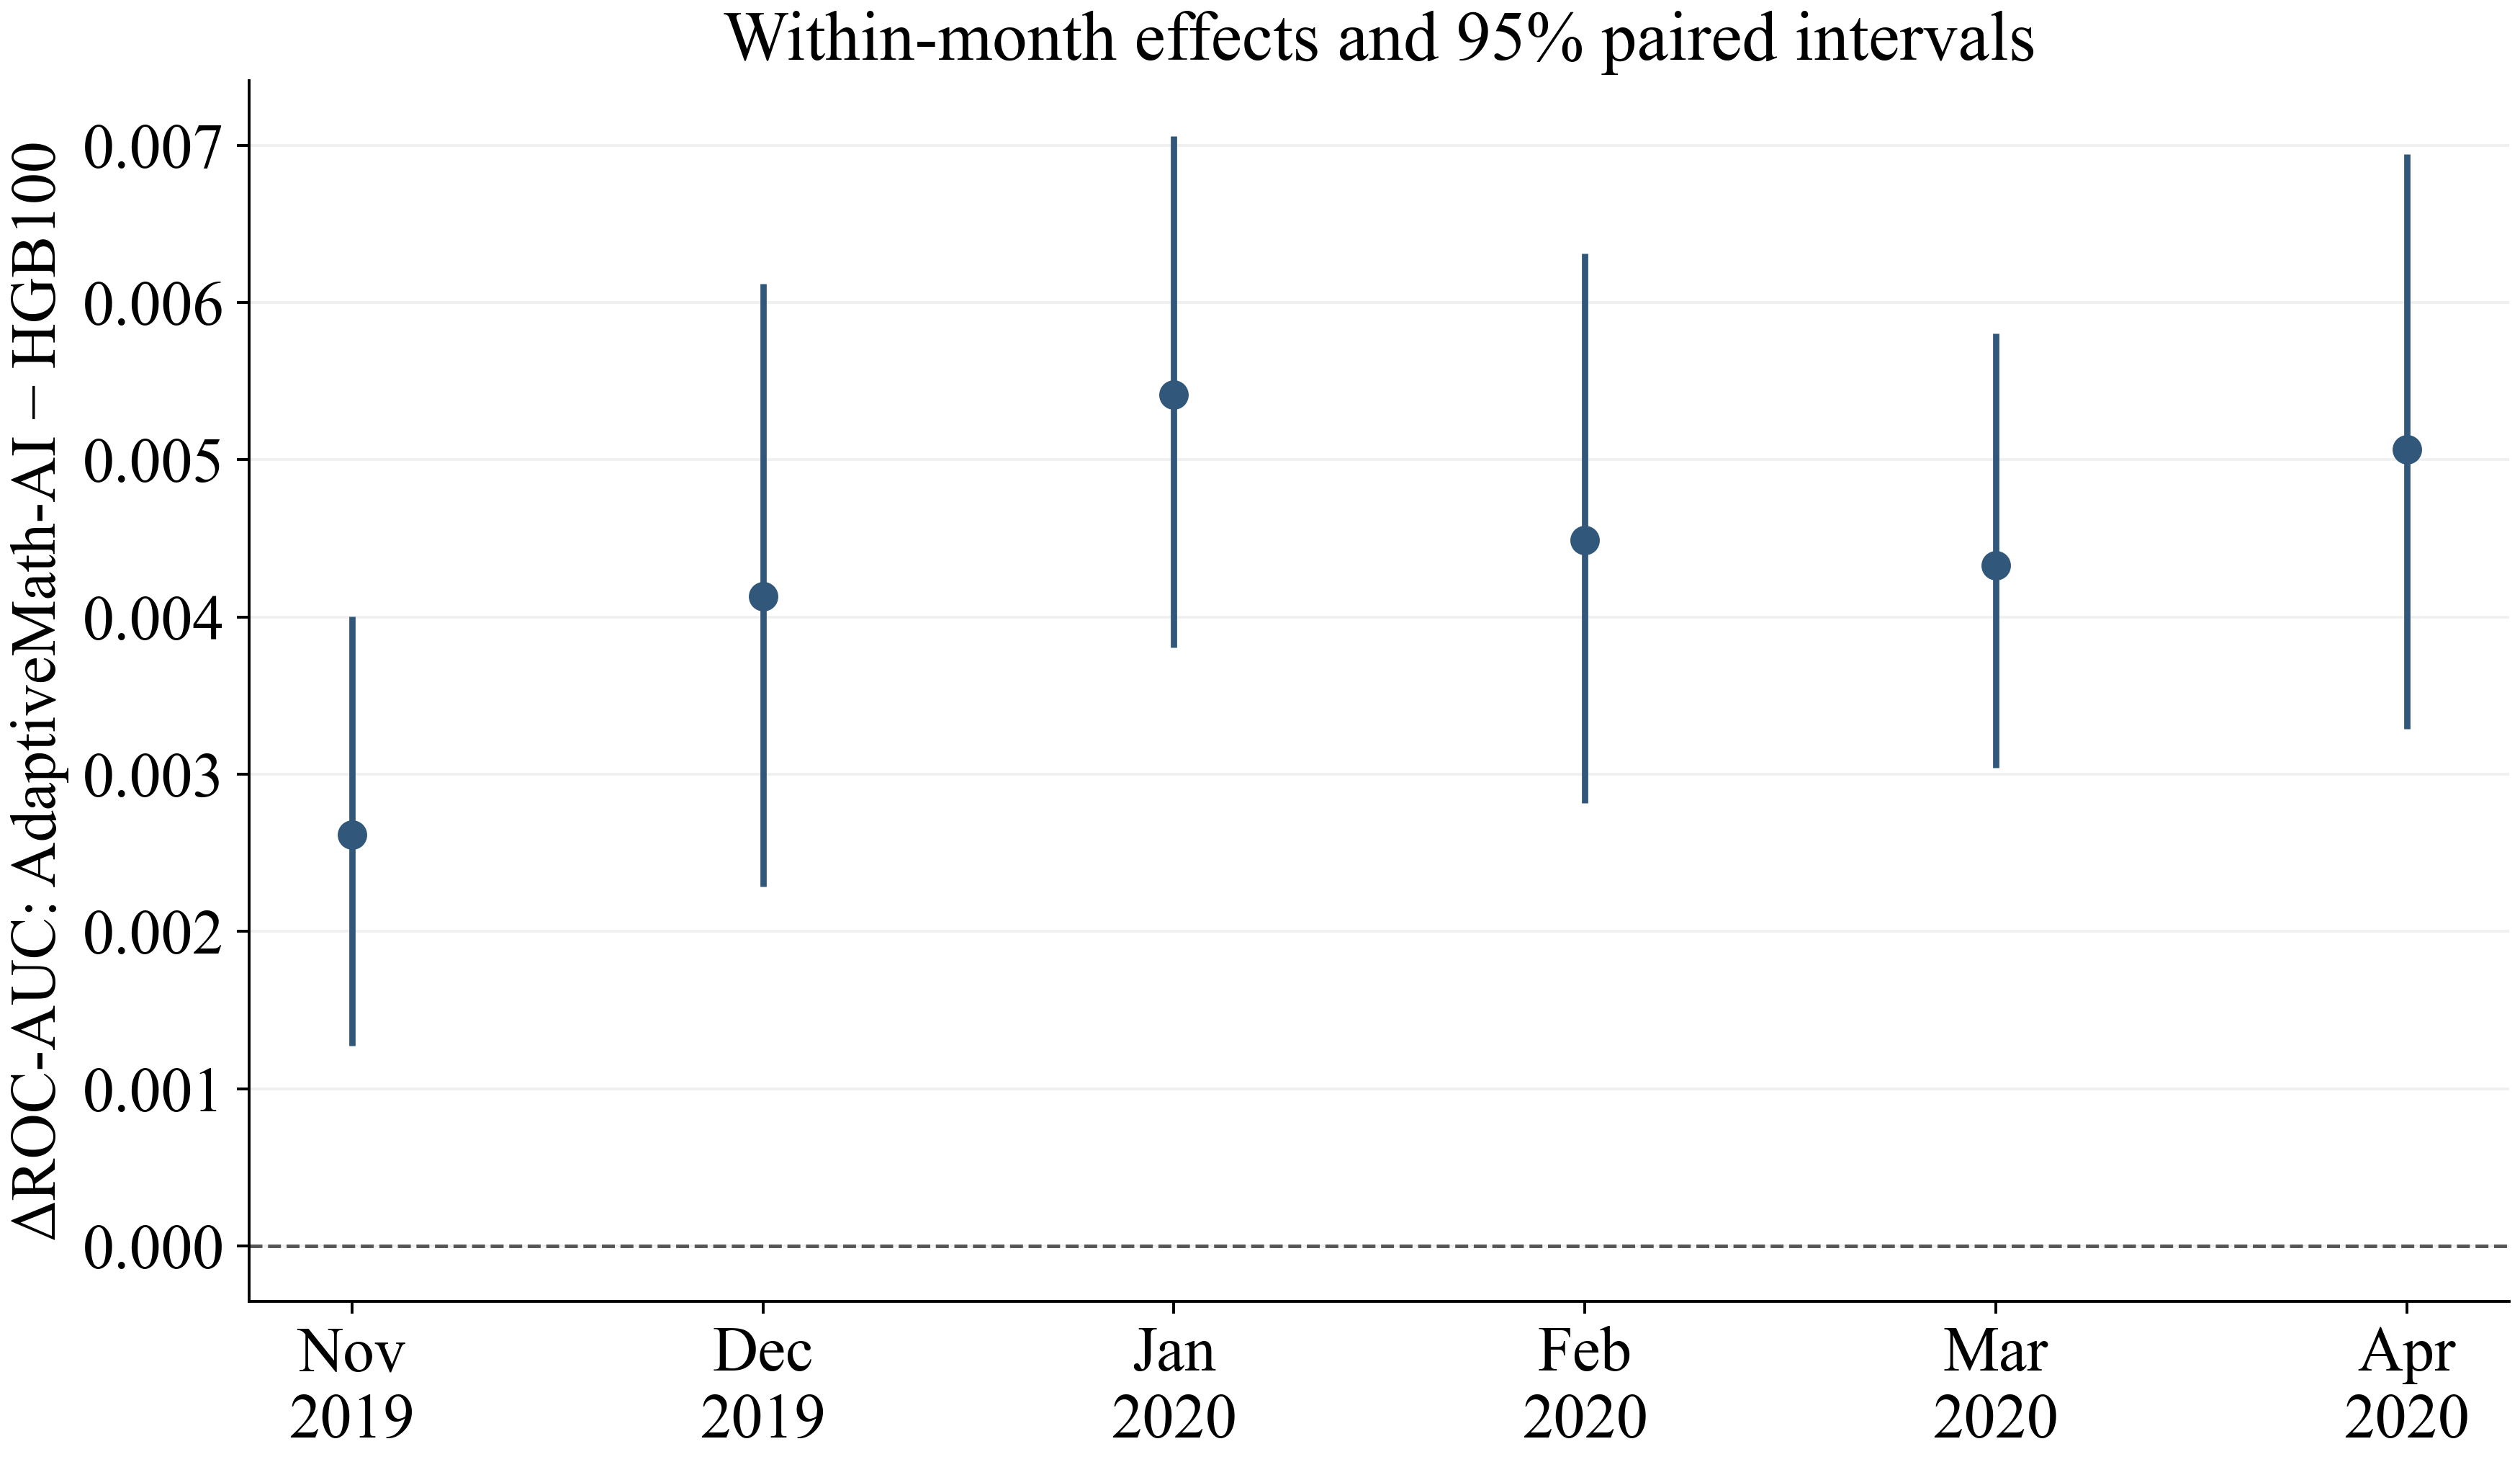

In [49]:
d=pd.read_csv(artifact_path("Tables/round2_window_model_differences.csv"))
d=d[d.metric.eq("ROC_AUC")].sort_values("window")
fig,ax=plt.subplots(figsize=(10,5.8),layout="constrained")
x=np.arange(len(d))
ax.vlines(x,d.lower,d.upper,color="#31577A",linewidth=1.8)
ax.scatter(x,d.delta,s=55,color="#31577A",zorder=3)
ax.axhline(0,color="#555555",linestyle="--",linewidth=1)
ax.set_xticks(x,["Nov\n2019","Dec\n2019","Jan\n2020","Feb\n2020","Mar\n2020","Apr\n2020"])
ax.set_ylabel("ΔROC-AUC: AdaptiveMath-AI − HGB100")
ax.set_title("Within-month effects and 95% paired intervals")
ax.spines[["top","right"]].set_visible(False);ax.grid(axis="y",alpha=.18)
save_canvas(fig,"round2_window_auc_differences")

## Probability calibration on the same targets
Calibration curves are evaluation diagnostics only. Both models retain their already fitted calibration mappings. Each point uses one of 15 fixed equal-width probability bins; empty bins are not plotted. Tail-bin estimates may contain few responses and fluctuate sharply; the connecting segments are descriptive, not confidence bands or evidence of a smooth calibration function.

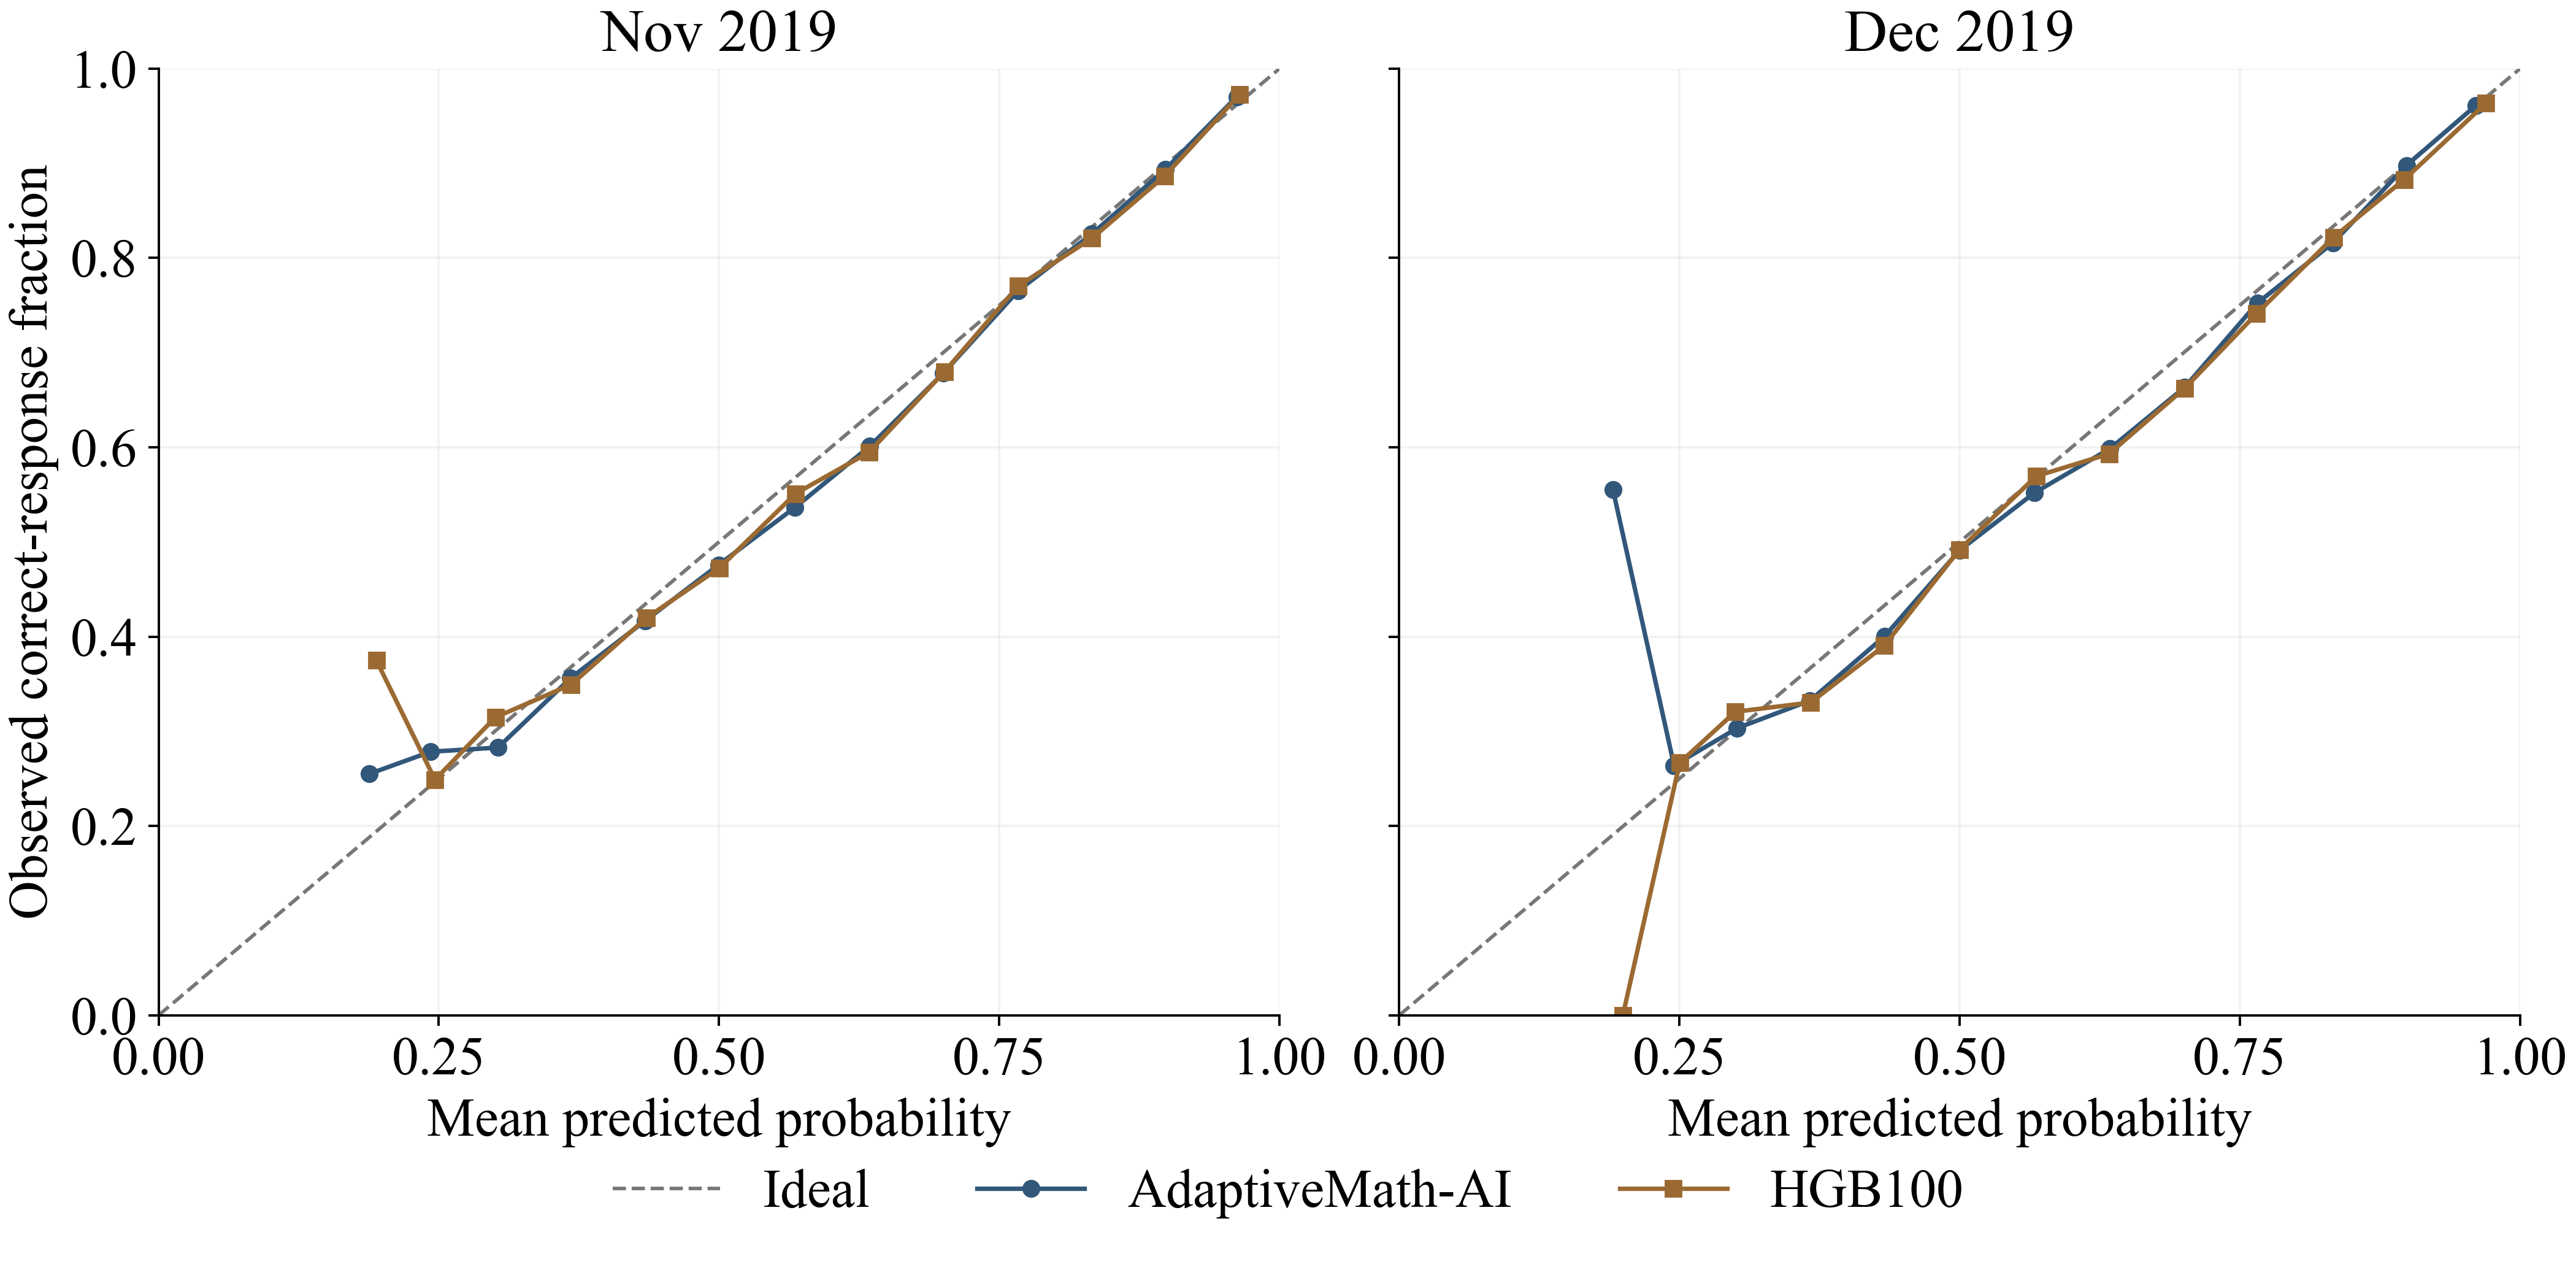

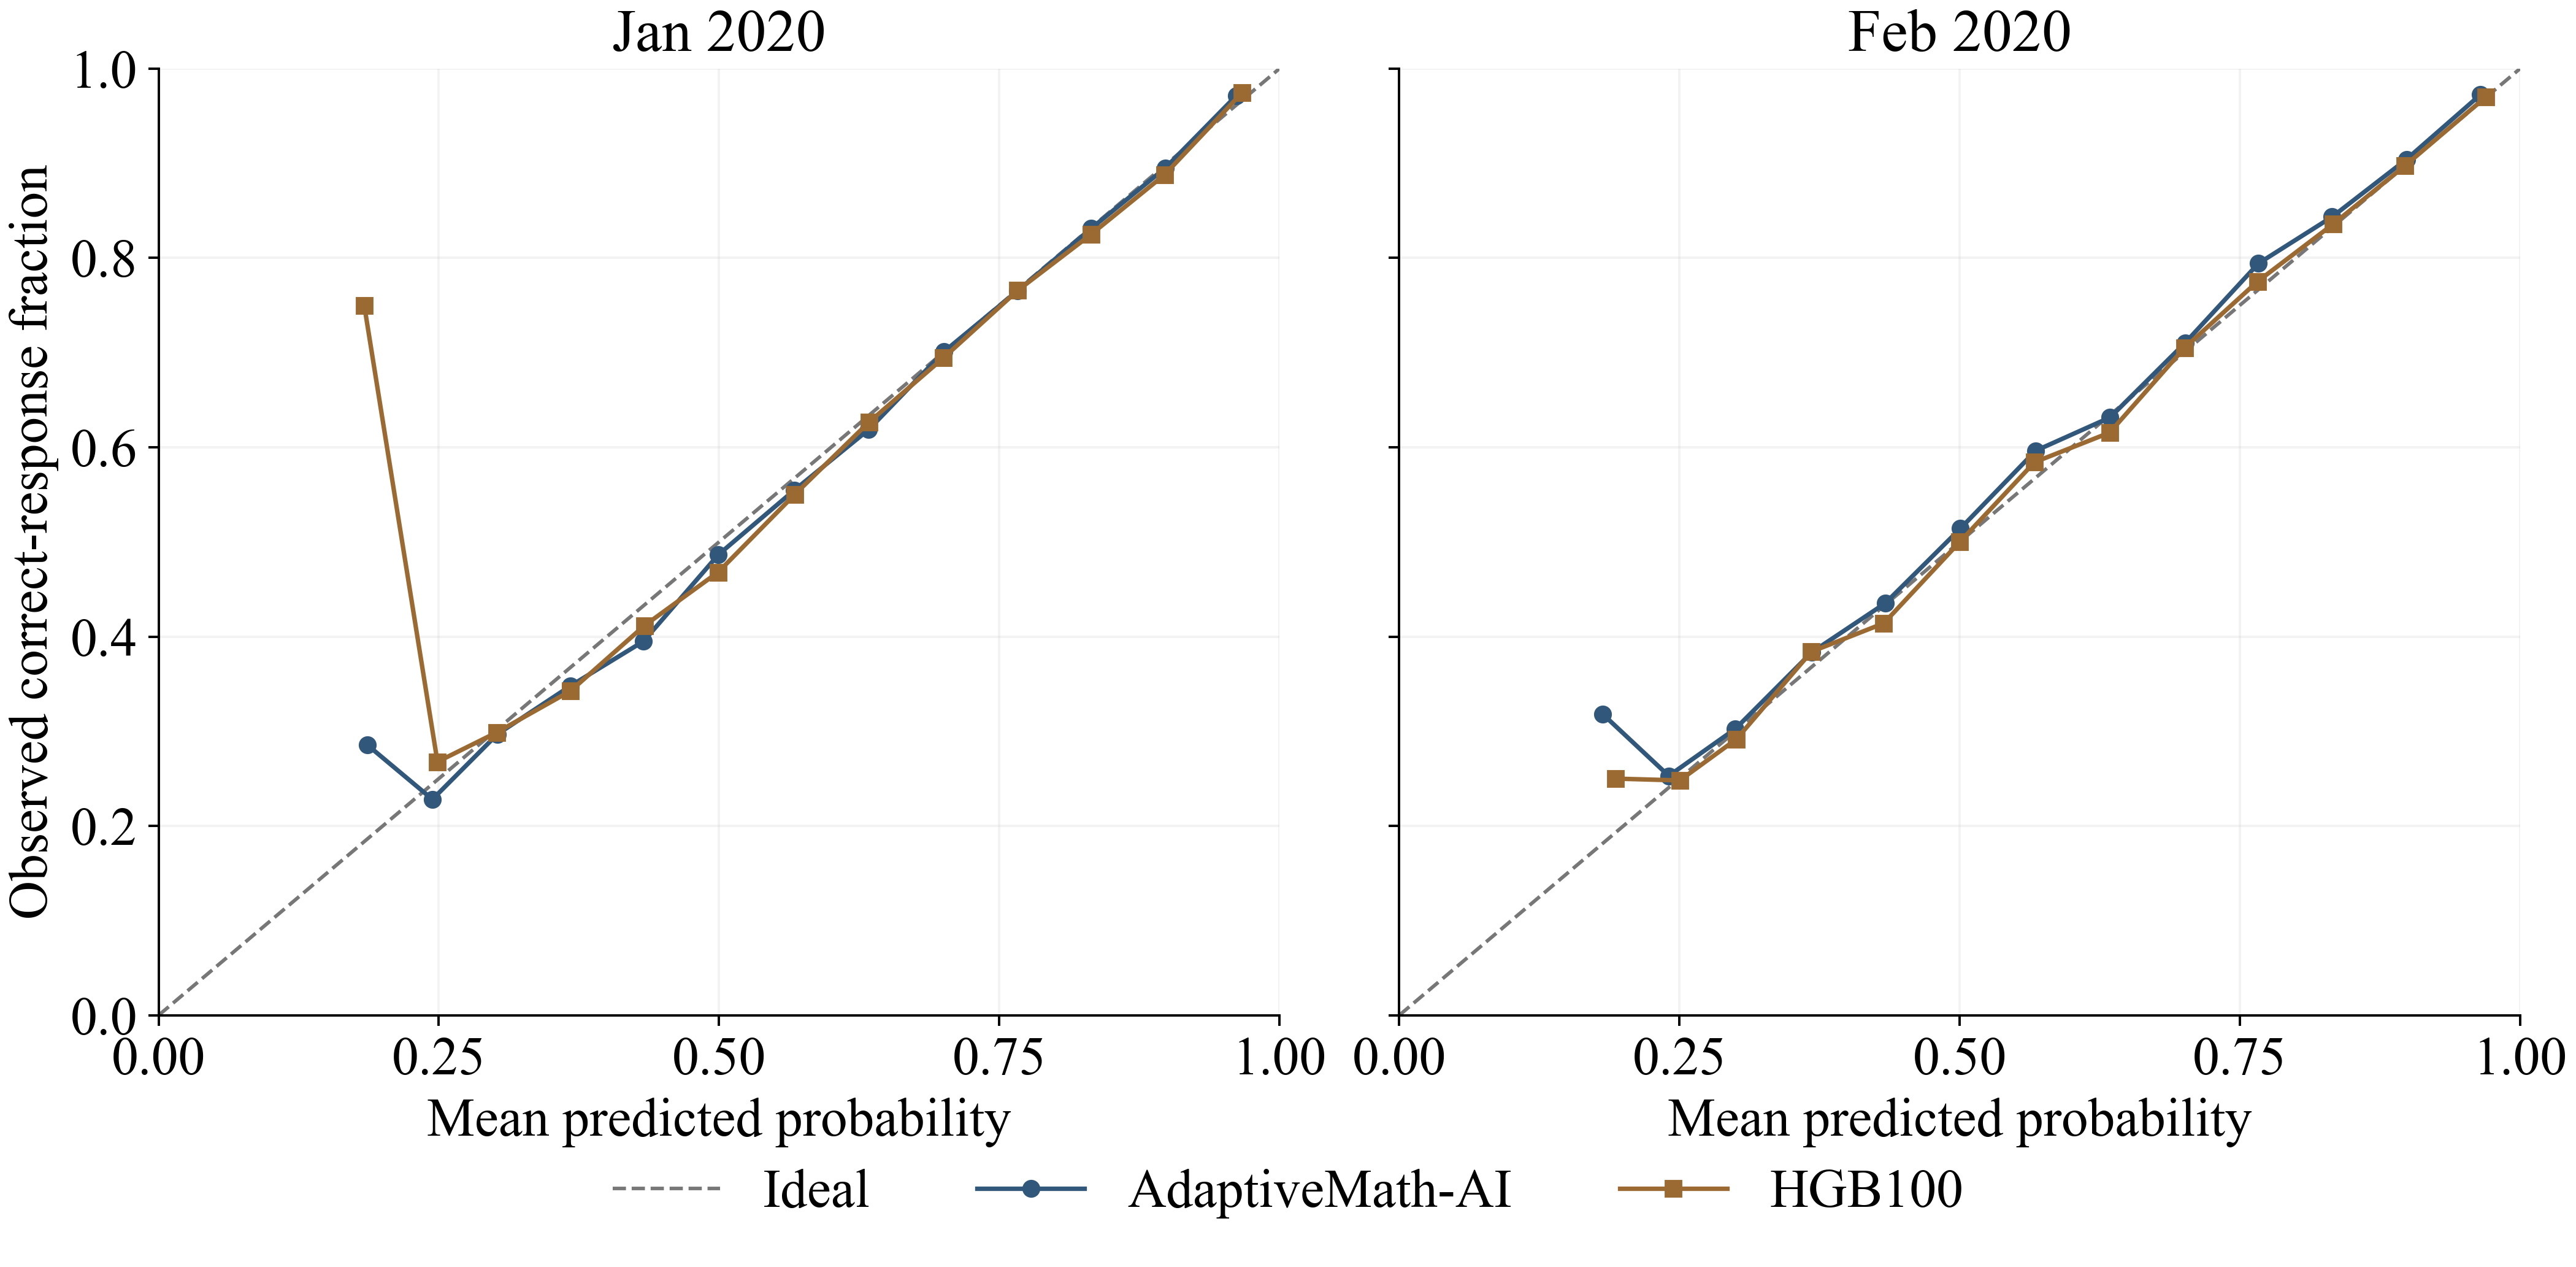

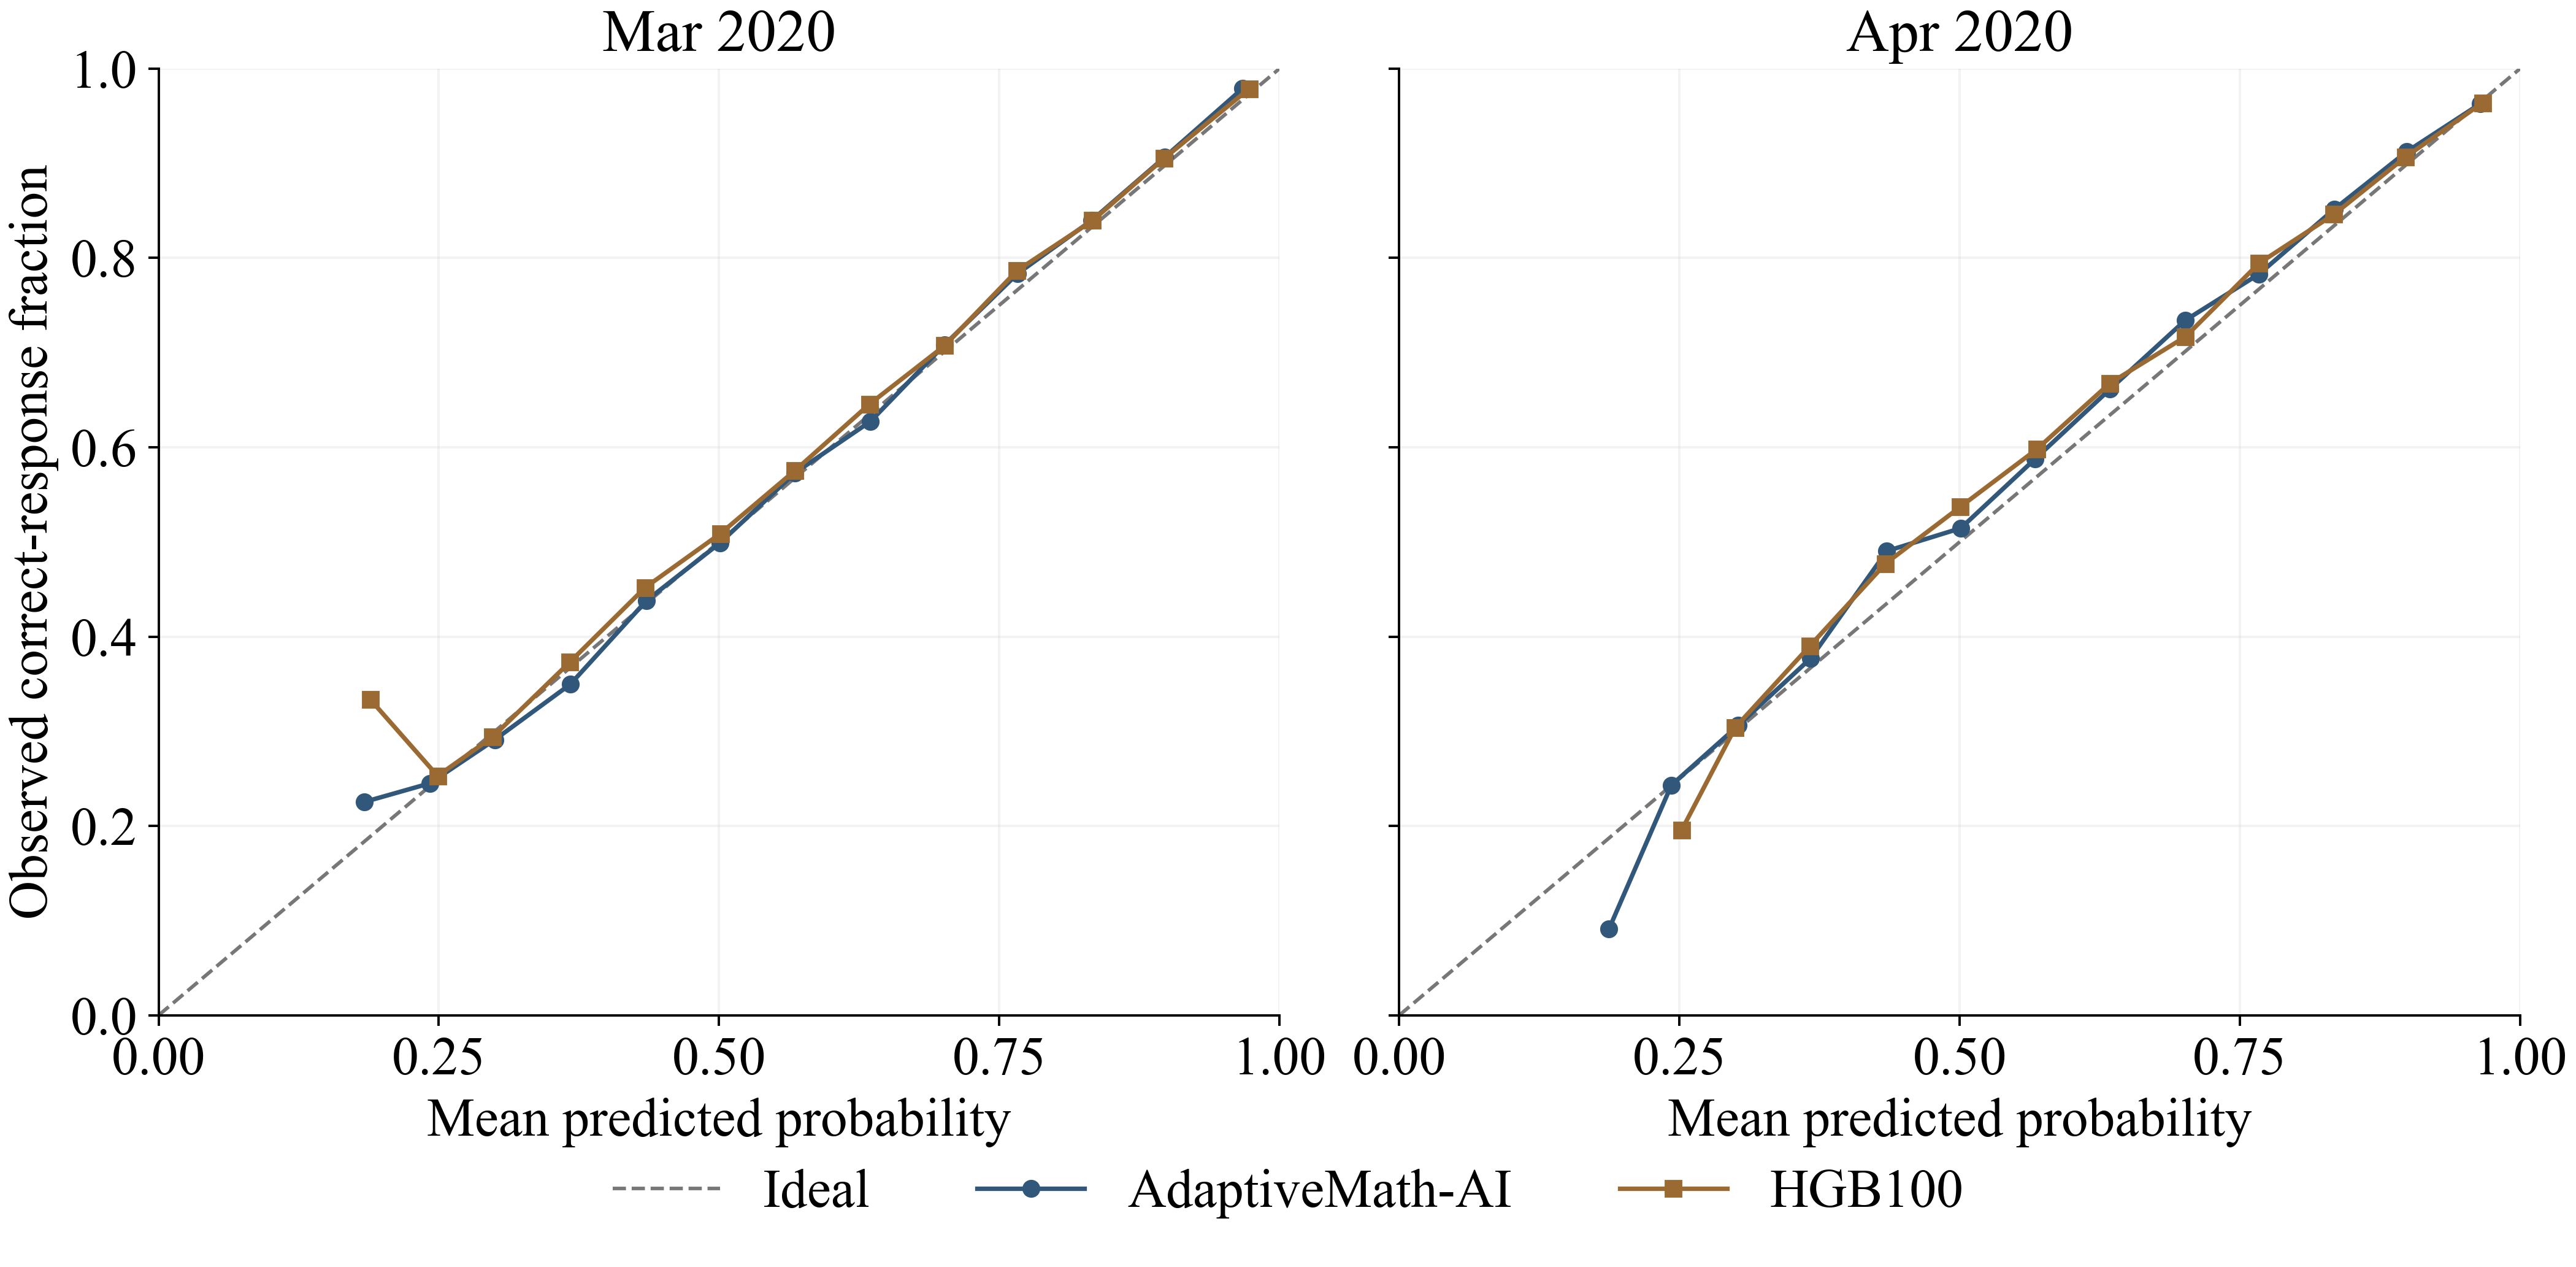

In [50]:
ensemble=pd.read_parquet(artifact_path("Data/round2_window_predictions.parquet"),
    columns=["model","fold","AnswerId","UserId","QuestionId","y","p","Gender","PremiumPupil","prior_interaction_count"],
    filters=[("model","in",["AdaptiveMath-AI","HGB100"])])
calibration=[]
for (model,fold),g in ensemble[ensemble.model.isin(["AdaptiveMath-AI","HGB100"])].groupby(["model","fold"]):
    bin_id=np.minimum((g.p*15).astype(int),14)
    for b,h in g.assign(Bin=bin_id).groupby("Bin"):
        calibration.append({"Model":model,"Window":fold+1,"Bin":b,"N":len(h),
            "Mean_probability":h.p.mean(),"Observed_fraction":h.y.mean()})
calibration=pd.DataFrame(calibration)
calibration.to_csv(artifact_path("Tables/monthly_calibration_bins15.csv"),index=False)
month_names=["Nov 2019","Dec 2019","Jan 2020","Feb 2020","Mar 2020","Apr 2020"]
for start in [1,3,5]:
    fig,axes=plt.subplots(1,2,figsize=(12,5.9),layout="constrained",sharex=True,sharey=True)
    for ax,window in zip(axes,[start,start+1]):
        ax.plot([0,1],[0,1],linestyle="--",color="#777777",linewidth=1.2,label="Ideal")
        for model,color,marker in [("AdaptiveMath-AI","#31577A","o"),("HGB100","#9B6A32","s")]:
            g=calibration[(calibration.Model==model)&(calibration.Window==window)].sort_values("Bin")
            ax.plot(g.Mean_probability,g.Observed_fraction,color=color,marker=marker,linewidth=1.5,markersize=5,label=model)
        ax.set(xlabel="Mean predicted probability",xlim=(0,1),ylim=(0,1));ax.set_title(month_names[window-1])
        ax.set_xticks([0,.25,.5,.75,1]);ax.spines[["top","right"]].set_visible(False);ax.grid(alpha=.15)
    axes[0].set_ylabel("Observed correct-response fraction")
    handles,labels=axes[0].get_legend_handles_labels()
    fig.legend(handles,labels,loc="outside lower center",ncol=3,frameon=False)
    save_canvas(fig,f"monthly_calibration_{start}_{start+1}")


## Pooled versus within-window discrimination
The same target responses support different estimands. A pooled AUC contains many positive/negative pairs from different months and is not substituted for the prespecified mean within-window effect.

In [51]:
pooled=r2.cross_window_diagnostic()
show_table(pooled.drop(columns="interpretation"),"Secondary pooled ranking and cross-window pairs",["model"],width=4)

**Secondary pooled ranking and cross-window pairs**

model,pooled_AUC_secondary_only,macro_within_window_AUC,response_weighted_within_window_AUC,same_window_pairs
AdaptiveMath-AI,0.764248,0.761173,0.761774,817326261
HGB80,0.760147,0.756927,0.757495,817326261
HGB100,0.760042,0.756833,0.757463,817326261


model,cross_window_pairs,same_window_pair_fraction,cross_window_pair_fraction
AdaptiveMath-AI,3887083943,0.173736,0.826264
HGB80,3887083943,0.173736,0.826264
HGB100,3887083943,0.173736,0.826264


## Missing hierarchy and matched control boundaries
Cohort properties are separated from synthetic robustness checks. A successful missing-key unit test does not imply that the observed cohort contained such cases.

In [52]:
with capture_output():
    hierarchy=r2.hierarchy_audit()
    information=r2.recency_information()
scientific=["primary_cohort_rows","missing_primary_subject_rows","missing_parent_rows","valid_question_missing_hierarchy"]
show_table(hierarchy[scientific].T.rename(columns={0:"Count"}).reset_index(names="Characteristic"),"Observed hierarchy coverage",["Characteristic"])
matched=information.groupby(["fold","variant"]).agg(Seeds=("seed","nunique"),Calibration_rows=("calibration_rows","first"),
    Target_rows=("target_rows","first"),Calibration_method=("calibration_method",lambda s:", ".join(sorted(s.unique()))),
    Matched_anchor_and_IDs=("matched_anchor_and_IDs",lambda s: bool(s.eq("PASS").all()))).reset_index()
show_table(matched,"Matched information opportunities",["fold","variant"],width=3)

**Observed hierarchy coverage**

Characteristic,Count
primary_cohort_rows,385037
missing_primary_subject_rows,0
missing_parent_rows,0
valid_question_missing_hierarchy,0


**Matched information opportunities**

fold,variant,Seeds,Calibration_rows,Target_rows
0,Question_only,10,35187,27181
0,RecentQuestionRateControl,10,35187,27181
1,Question_only,10,41822,15987
1,RecentQuestionRateControl,10,41822,15987
2,Question_only,10,45486,27052
2,RecentQuestionRateControl,10,45486,27052
3,Question_only,10,52718,22348
3,RecentQuestionRateControl,10,52718,22348
4,Question_only,10,57051,31522
4,RecentQuestionRateControl,10,57051,31522


fold,variant,Calibration_method,Matched_anchor_and_IDs
0,Question_only,none,True
0,RecentQuestionRateControl,none,True
1,Question_only,none,True
1,RecentQuestionRateControl,none,True
2,Question_only,none,True
2,RecentQuestionRateControl,none,True
3,Question_only,platt,True
3,RecentQuestionRateControl,platt,True
4,Question_only,none,True
4,RecentQuestionRateControl,none,True


## Subgroup and history calibration
These are descriptive diagnostics on frozen evaluation predictions, not claims of demographic causality or proof of fairness. Missing demographic values remain explicit categories. Small or one-class groups do not support AUC or a stable calibration slope.

In [53]:
import revision_models as rm
from scipy.special import xlogy
ensemble["History"]=pd.cut(ensemble.prior_interaction_count,[-1,0,5,20,50,np.inf],
    labels=["0","1–5","6–20","21–50",">50"])
rows=[]
for dimension in ["Gender","PremiumPupil","History"]:
    for (model,group),g in ensemble.groupby(["model",dimension],dropna=False,observed=True):
        value="Missing" if pd.isna(group) else str(group)
        result=rm.metrics(g.y,g.p)
        rows.append({"Model":model,"Dimension":dimension,"Group":value,"N":len(g),"Learners":g.UserId.nunique(),
            "Correct fraction":g.y.mean(),"ROC_AUC":result["ROC_AUC"],"Brier":result["Brier"],
            "ECE15":result["ECE15"],"Calibration intercept":result["Calibration_Intercept"],"Calibration slope":result["Calibration_Slope"]})
subgroups=pd.DataFrame(rows)
subgroups.to_csv(artifact_path("Tables/frozen_subgroup_calibration.csv"),index=False)
show_table(subgroups,"Frozen subgroup and history diagnostics",["Model","Dimension","Group","N"],width=3)
def ece_probability(y,p,bins=15,strategy="equal_width"):
    index=np.minimum((p*bins).astype(int),bins-1) if strategy=="equal_width" else pd.qcut(p,bins,labels=False,duplicates="drop")
    d=pd.DataFrame({"y":np.asarray(y),"p":np.asarray(p),"bin":index})
    parts=d.groupby("bin",dropna=False).agg(n=("y","size"),observed=("y","mean"),predicted=("p","mean"))
    return np.sum(parts.n*np.abs(parts.observed-parts.predicted))/len(d)
binning=[]
weighting=[]
for model,g in ensemble.groupby("model"):
    for bins,strategy in [(10,"equal_width"),(15,"equal_width"),(15,"equal_frequency")]:
        binning.append({"Model":model,"Bins requested":bins,"Strategy":strategy,"ECE":ece_probability(g.y.to_numpy(),g.p.to_numpy(),bins,strategy)})
    learner=g.assign(Squared_error=(g.y-g.p)**2,Log_loss=-(xlogy(g.y,g.p)+xlogy(1-g.y,1-g.p))).groupby("UserId")[["Squared_error","Log_loss"]].mean()
    weighting.append({"Model":model,"Learners":len(learner),"Equal-learner Brier":learner.Squared_error.mean(),"Equal-learner log loss":learner.Log_loss.mean()})
show_table(pd.DataFrame(binning),"Separate calibration-binning sensitivity",["Model"],width=3)
show_table(pd.DataFrame(weighting),"Equal-learner weighting",["Model"],width=3)

**Frozen subgroup and history diagnostics**

Model,Dimension,Group,N,Learners,Correct fraction,ROC_AUC
AdaptiveMath-AI,Gender,0,40515,422,0.669727,0.782695
AdaptiveMath-AI,Gender,1,54152,654,0.643744,0.750698
AdaptiveMath-AI,Gender,2,48885,586,0.6332,0.762492
AdaptiveMath-AI,Gender,3,13,1,0.615385,0.85
HGB100,Gender,0,40515,422,0.669727,0.777594
HGB100,Gender,1,54152,654,0.643744,0.746794
HGB100,Gender,2,48885,586,0.6332,0.758641
HGB100,Gender,3,13,1,0.615385,0.85
AdaptiveMath-AI,PremiumPupil,0.0,36053,349,0.596927,0.74251
AdaptiveMath-AI,PremiumPupil,1.0,9107,105,0.5252,0.737561


Model,Dimension,Group,N,Brier,ECE15,Calibration intercept
AdaptiveMath-AI,Gender,0,40515,0.173737,0.013192,-0.057128
AdaptiveMath-AI,Gender,1,54152,0.189119,0.005703,-0.005672
AdaptiveMath-AI,Gender,2,48885,0.187499,0.006052,-0.007337
AdaptiveMath-AI,Gender,3,13,0.182267,0.323429,-1.269554
HGB100,Gender,0,40515,0.175439,0.009848,-0.049885
HGB100,Gender,1,54152,0.19035,0.005388,-0.00337
HGB100,Gender,2,48885,0.188774,0.006016,-0.003938
HGB100,Gender,3,13,0.177641,0.316721,-0.936806
AdaptiveMath-AI,PremiumPupil,0.0,36053,0.199766,0.007464,-0.002576
AdaptiveMath-AI,PremiumPupil,1.0,9107,0.20752,0.023018,-0.102979


Model,Dimension,Group,N,Calibration slope
AdaptiveMath-AI,Gender,0,40515,1.083422
AdaptiveMath-AI,Gender,1,54152,1.013306
AdaptiveMath-AI,Gender,2,48885,1.005414
AdaptiveMath-AI,Gender,3,13,1.951083
HGB100,Gender,0,40515,1.055123
HGB100,Gender,1,54152,1.001747
HGB100,Gender,2,48885,0.985415
HGB100,Gender,3,13,1.599169
AdaptiveMath-AI,PremiumPupil,0.0,36053,0.958268
AdaptiveMath-AI,PremiumPupil,1.0,9107,0.977731


Model,Dimension,Group,N,Learners,Correct fraction,ROC_AUC
AdaptiveMath-AI,History,>50,98352,1314,0.635605,0.77466
HGB100,History,0,965,660,0.709845,0.569528
HGB100,History,1–5,3394,665,0.688273,0.700233
HGB100,History,6–20,11652,845,0.682715,0.730298
HGB100,History,21–50,29202,1183,0.666632,0.735609
HGB100,History,>50,98352,1314,0.635605,0.771119


...

Model,Dimension,Group,N,Calibration slope
AdaptiveMath-AI,History,>50,98352,1.025186
HGB100,History,0,965,0.897889
HGB100,History,1–5,3394,0.986774
HGB100,History,6–20,11652,1.014877
HGB100,History,21–50,29202,1.000307
HGB100,History,>50,98352,1.010955


**Separate calibration-binning sensitivity**

Model,Bins requested,Strategy,ECE
AdaptiveMath-AI,10,equal_width,0.00686
AdaptiveMath-AI,15,equal_width,0.006268
AdaptiveMath-AI,15,equal_frequency,0.006919
HGB100,10,equal_width,0.003965
HGB100,15,equal_width,0.005063
HGB100,15,equal_frequency,0.004751


**Equal-learner weighting**

Model,Learners,Equal-learner Brier,Equal-learner log loss
AdaptiveMath-AI,1663,0.188106,0.554792
HGB100,1663,0.189521,0.558199


## Review prioritization at equal budgets
Review means inspecting a model's classification errors at the fixed 0.5 threshold; it is not a demonstrated educational intervention. Entropy, 1−p and a seeded random ranking inspect exactly the same number of responses for each budget.

In [54]:
review=[]
for model,g in ensemble.groupby("model"):
    g=g.sort_values("AnswerId")
    p=g.p.to_numpy();error=(g.y.to_numpy()!=(p>=.5))
    rng=np.random.default_rng(20260713)
    scores={"Entropy":-(xlogy(p,p)+xlogy(1-p,1-p)),"1 − p":1-p,"Random":rng.random(len(g))}
    for budget in rd.protocol()["review_budgets"]:
        n=int(np.floor(budget*len(g)))
        for policy,score in scores.items():
            chosen=np.argsort(-score,kind="stable")[:n]
            review.append({"Model":model,"Review fraction":budget,"Policy":policy,"Reviewed":n,
                "Errors found":int(error[chosen].sum()),"Error precision":error[chosen].mean(),
                "Fraction of all errors found":error[chosen].sum()/max(error.sum(),1)})
review=pd.DataFrame(review)
review.to_csv(artifact_path("Tables/frozen_equal_budget_review.csv"),index=False)
show_table(review,"Equal-budget review yield",["Model","Review fraction","Policy"],width=4)

**Equal-budget review yield**

Model,Review fraction,Policy,Reviewed,Errors found,Error precision,Fraction of all errors found
AdaptiveMath-AI,0.05,Entropy,7178,3474,0.483979,0.086338
AdaptiveMath-AI,0.05,1 − p,7178,1878,0.261633,0.046673
AdaptiveMath-AI,0.05,Random,7178,2024,0.281973,0.050302
AdaptiveMath-AI,0.1,Entropy,14356,6821,0.475132,0.169521
AdaptiveMath-AI,0.1,1 − p,14356,4137,0.288172,0.102816
AdaptiveMath-AI,0.1,Random,14356,4024,0.280301,0.100007
AdaptiveMath-AI,0.2,Entropy,28713,12985,0.452234,0.322713
AdaptiveMath-AI,0.2,1 − p,28713,9618,0.33497,0.239034
AdaptiveMath-AI,0.2,Random,28713,8093,0.281858,0.201133
AdaptiveMath-AI,0.3,Entropy,43069,18612,0.432144,0.462559


Model,Review fraction,Policy,Reviewed,Errors found,Error precision,Fraction of all errors found
HGB100,0.2,Entropy,28713,12949,0.45098,0.319067
HGB100,0.2,1 − p,28713,9785,0.340786,0.241105
HGB100,0.2,Random,28713,8180,0.284888,0.201557
HGB100,0.3,Entropy,43069,18559,0.430913,0.457298
HGB100,0.3,1 − p,43069,16455,0.382061,0.405455
HGB100,0.3,Random,43069,12225,0.283847,0.301227


## Warm event-stream inference cost
Timing includes timestamp-batch materialization, feature emission, frozen-model prediction, calibration and state update. Historical-state preparation, model loading and disk I/O are excluded and stated separately. The first complete timestamp batches covering at least 1,000 November responses form the fixed timing segment; no best-case batch is selected.

In [55]:
import time,copy,joblib
from threadpoolctl import threadpool_limits
events=pd.read_parquet(artifact_path("Data")/("events_"+rd.protocol()["cohort"]["salt"]+".parquet"))
start=pd.Timestamp(rd.protocol()["calendar"]["outer_edges"][0],tz="UTC")
factors,_=rd.fit_representation(events,rd.protocol()["calendar"]["representation_end"])
state=rd.EventReplay(factors=factors,item_fit_end=rd.protocol()["calendar"]["representation_end"])
warm_started=time.perf_counter()
for stamp,g in events[events.DateAnswered<start].groupby("DateAnswered",sort=True):
    state.update_batch(list(g.itertuples(index=False)),stamp)
for user in list(state.hist):state.learner(user)
warm_seconds=time.perf_counter()-warm_started
future=events[events.DateAnswered>=start].sort_values(["DateAnswered","AnswerId"])
end=future.iloc[min(999,len(future)-1)].DateAnswered
segment=future[future.DateAnswered<=end]
feature_reference=pd.read_parquet(artifact_path("Data/features_primary.parquet")).set_index("AnswerId")
seed=rd.protocol()["seeds"][0]
reference=pd.read_parquet(artifact_path("Data")/f"round2_predictions_seed{seed}_fold0.parquet").set_index(["model","AnswerId"])
latencies=[];summaries=[]
with threadpool_limits(limits=4):
    for model in ["AdaptiveMath-AI","HGB100"]:
        replay=copy.deepcopy(state)
        obj=joblib.load(artifact_path("Models")/f'round2_{model.replace("-","_")}_seed{seed}_fold0.joblib')
        elapsed=[];counts=[]
        for stamp,g in segment.groupby("DateAnswered",sort=True):
            tic=time.perf_counter()
            batch=list(g.itertuples(index=False))
            values=replay.emit_batch(batch)
            frame=pd.DataFrame(values,columns=rd.FEATURES)
            for column in ["AnswerId","QuestionId","primary_subject_id","parent_subject_id"]:
                frame[column]=g[column].to_numpy()
            probability,_=rm.reconstruct(obj,frame)
            replay.update_batch(batch,stamp)
            seconds=time.perf_counter()-tic
            np.testing.assert_allclose(values,feature_reference.loc[g.AnswerId,rd.FEATURES].to_numpy(),rtol=0,atol=1e-12,equal_nan=True)
            expected=reference.loc[[(model,int(a)) for a in g.AnswerId],"p"].to_numpy()
            np.testing.assert_allclose(probability,expected,rtol=0,atol=1e-12)
            elapsed.append(seconds);counts.append(len(g))
            latencies.append({"Model":model,"Timestamp":stamp,"Responses":len(g),"Seconds":seconds})
        per_response=1000*np.asarray(elapsed)/np.asarray(counts)
        summaries.append({"Model":model,"Responses":sum(counts),"Timestamp batches":len(counts),
            "State preparation (s)":warm_seconds,"Mean amortized ms/response":1000*sum(elapsed)/sum(counts),
            "Median batch-amortized ms/response":np.median(per_response),"P95 batch-amortized ms/response":np.quantile(per_response,.95),
            "Responses per second":sum(counts)/sum(elapsed)})
pd.DataFrame(latencies).to_csv(artifact_path("Tables/warm_event_stream_latency.csv"),index=False)
show_table(pd.DataFrame(summaries),"Measured warm event-stream computation",["Model"],width=3)

**Measured warm event-stream computation**

Model,Responses,Timestamp batches,State preparation (s)
AdaptiveMath-AI,1000,561,45.22404
HGB100,1000,561,45.22404


Model,Mean amortized ms/response,Median batch-amortized ms/response,P95 batch-amortized ms/response
AdaptiveMath-AI,7.394766,12.442,14.41275
HGB100,1.806414,2.594416,4.731166


Model,Responses per second
AdaptiveMath-AI,135.230781
HGB100,553.582964


Latency is one local warm-process measurement on a specified chronological segment, not a service-level guarantee or a comparison of complete training costs. The counterfactual review analysis does not establish learning gains. Subgroup tables and binning sensitivity do not replace clustered uncertainty. Broad distribution-shift or external-transfer claims are not made without corresponding independent evidence.

## Conclusions and limits
The strongest supported improvement is over the matched HGB control; an additional advantage over question-only residual correction is not established. Null and negative component effects are retained. Several hybrid variants yield identical predictions across seeds under this fixed protocol, so ten seed labels do not create ten independent confirmations.

Completion-time ordering cannot recover presentation-time causality. Content hierarchy is treated as static metadata because version times are unavailable. The resampling intervals are conditional, the source is previously studied, and no independent confirmation or broad superiority over canonical neural models is claimed. Supporting fixed-split diagnostics must remain separate from the six-window primary evaluation.

## Reproducibility checks
The following silent cell checks numerical reproduction and writes technical provenance separately; these checks are not additional scientific outcomes.

In [5]:
with capture_output():
    clean_checks=r2.compare_clean_run()
    assert clean_checks.result.eq("PASS").all()
    r2.coverage()
    r2.execution_manifest()